# Model Validation

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import statsmodels.api as sm
from scipy import stats
from scipy.stats import lognorm
from sklearn.metrics import roc_auc_score
warnings.simplefilter(action='ignore', category=FutureWarning)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from scipy import stats
from sklearn.utils import resample
from sklearn.metrics import brier_score_loss
from scipy.stats import norm, binom
from scipy.integrate import quad
from scipy.special import logit, expit
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression


In [45]:
csvs_path = [rf'datasets/{name}.csv' for name in ['hmeq', 'lgd', 'ratings', 'mortgage']]
hmeq, lgd, ratings, mortgage = list(map(pd.read_csv, csvs_path))

Let us now assume that our PD, LGD, EAD models have been built. The next step is to then put them into production and start monitoring or validating them. 

### Regulatory Perspective


Banks must conduct validation on a regular basis. This usually occurs on a monthly basis and sometimes even more frequently. The more frequently it's undertaken, the more quickly performance deviations or other critical issues can be detected. It also needs the proper documentation.

It's important to remember that the validation is not only about the estimation of all relevant risk parameters, which constitutes a narrows view on validation, but also about the accuracy and consistency of the rating syustems and processes as a whole.

Some examples are:

- Backtesting, for example, comparing the default rates with the estimated PDs
- Benchmarking, compare internal models and/or estimates with an external reference model and/or estimates to find model deficiencies and identify opportunities for improvement.
- Model stability, the outputs of models and validation results should not systematically change over time

The book has given us the framework below for validation.

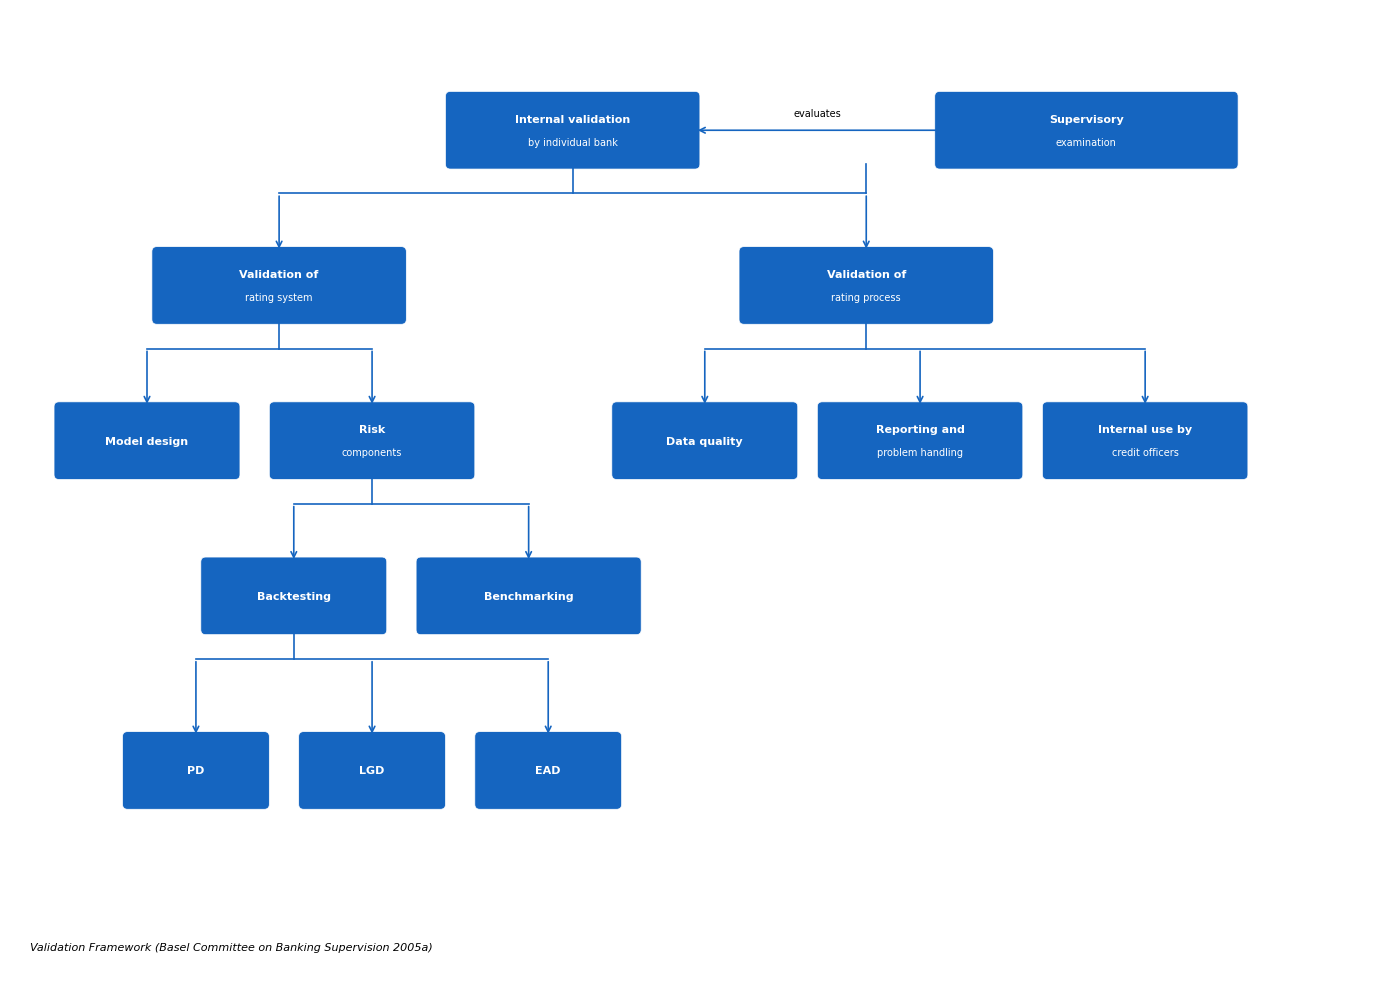

In [46]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

BOX_COLOR = '#1565C0'
TEXT_COLOR = 'white'
FONT = dict(color=TEXT_COLOR, ha='center', va='center', fontsize=8, fontweight='bold')

def draw_box(ax, x, y, w, h, label, label2=None):
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle="round,pad=0.05",
                         facecolor=BOX_COLOR,
                         edgecolor='white',
                         linewidth=0.5)
    ax.add_patch(box)
    cy = y + h / 2
    if label2:
        ax.text(x + w/2, cy + 0.12, label,  **FONT)
        ax.text(x + w/2, cy - 0.12, label2, **{**FONT, 'fontweight': 'normal', 'fontsize': 7})
    else:
        ax.text(x + w/2, cy, label, **FONT)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=BOX_COLOR, lw=1.2))

def hline(ax, x1, x2, y):
    ax.plot([x1, x2], [y, y], color=BOX_COLOR, lw=1.2)

def vline(ax, x, y1, y2):
    ax.plot([x, x], [y1, y2], color=BOX_COLOR, lw=1.2)

# ── Nodes ────────────────────────────────────────────────────────
# Internal validation (top center)
draw_box(ax, 4.5, 8.4, 2.5, 0.7, 'Internal validation', 'by individual bank')

# Supervisory examination (top right)
draw_box(ax, 9.5, 8.4, 3.0, 0.7, 'Supervisory', 'examination')

# Validation of rating system / process
draw_box(ax, 1.5, 6.8, 2.5, 0.7, 'Validation of', 'rating system')
draw_box(ax, 7.5, 6.8, 2.5, 0.7, 'Validation of', 'rating process')

# Model design, Risk components
draw_box(ax, 0.5, 5.2, 1.8, 0.7, 'Model design')
draw_box(ax, 2.7, 5.2, 2.0, 0.7, 'Risk', 'components')

# Data quality, Reporting, Internal use
draw_box(ax, 6.2, 5.2, 1.8, 0.7, 'Data quality')
draw_box(ax, 8.3, 5.2, 2.0, 0.7, 'Reporting and', 'problem handling')
draw_box(ax, 10.6, 5.2, 2.0, 0.7, 'Internal use by', 'credit officers')

# Backtesting, Benchmarking
draw_box(ax, 2.0, 3.6, 1.8, 0.7, 'Backtesting')
draw_box(ax, 4.2, 3.6, 2.2, 0.7, 'Benchmarking')

# PD, LGD, EAD
draw_box(ax, 1.2, 1.8, 1.4, 0.7, 'PD')
draw_box(ax, 3.0, 1.8, 1.4, 0.7, 'LGD')
draw_box(ax, 4.8, 1.8, 1.4, 0.7, 'EAD')

# ── Connectors ───────────────────────────────────────────────────
# evaluates arrow (right to left)
ax.annotate('', xy=(7.0, 8.75), xytext=(9.5, 8.75),
            arrowprops=dict(arrowstyle='->', color=BOX_COLOR, lw=1.2))
ax.text(8.25, 8.9, 'evaluates', ha='center', fontsize=7, color='black')

# Internal validation → branches
vline(ax, 5.75, 8.4, 8.1);  hline(ax, 2.75, 8.75, 8.1)
arrow(ax, 2.75, 8.1, 2.75, 7.5);  arrow(ax, 8.75, 8.1, 8.75, 7.5)
vline(ax, 8.75, 8.1, 8.4)

# Rating system → model design + risk components
vline(ax, 2.75, 6.8, 6.5);  hline(ax, 1.4, 3.7, 6.5)
arrow(ax, 1.4, 6.5, 1.4, 5.9);  arrow(ax, 3.7, 6.5, 3.7, 5.9)

# Rating process → data quality, reporting, internal use
vline(ax, 8.75, 6.8, 6.5);  hline(ax, 7.1, 11.6, 6.5)
arrow(ax, 7.1, 6.5, 7.1, 5.9)
arrow(ax, 9.3, 6.5, 9.3, 5.9)
arrow(ax, 11.6, 6.5, 11.6, 5.9)

# Risk components → backtesting + benchmarking
vline(ax, 3.7, 5.2, 4.9);  hline(ax, 2.9, 5.3, 4.9)
arrow(ax, 2.9, 4.9, 2.9, 4.3);  arrow(ax, 5.3, 4.9, 5.3, 4.3)

# Backtesting/benchmarking → PD, LGD, EAD
vline(ax, 2.9, 3.6, 3.3);  hline(ax, 1.9, 5.5, 3.3)
arrow(ax, 1.9, 3.3, 1.9, 2.5)
arrow(ax, 3.7, 3.3, 3.7, 2.5)
arrow(ax, 5.5, 3.3, 5.5, 2.5)

# ── Caption ──────────────────────────────────────────────────────
ax.text(0.2, 0.3,
        'Validation Framework (Basel Committee on Banking Supervision 2005a)',
        fontsize=8, fontstyle='italic', color='black')

plt.tight_layout()
plt.savefig('validation_framework.png', dpi=150, bbox_inches='tight')
plt.show()

#### Common Validation Issues

Banks employ a wide range of techniques to validate internal ratings, and the techniques used to assess corporate and retail ratings are substantially different. One of the reasons behind that is that contrary to retail portfolios, in many corporate portfolios data availability is paramount.

Rating validation is not an exact science. Absolute performance measures are considered counterproductive by some institutions. It is challenging to derive minimum performance benchmarks that PD, LGD and EAD models need to achieve in order to be considered satisfactory. So, any performance metric reported should be interpreted in terms of its own specific context and expert judgment is critical.

### General Validation Principles

Here, you can see some General Validation Principles put forward by the Basel Committee Validation Subgroup; see Basel Committee on Banking Supervision (2005b).

* **Principle 1:** *Validation is fundamentally about assessing the predictive ability of a bank's risk estimates and the use of ratings in credit processes.*
    This refers to the ideas of backtesting and use testing.
* **Principle 2:** *The bank has the primary responsibility for validation;*
    The supervisor does not perform the validation; the bank has this responsibility. The supervisor reviews the validation only.
* **Principle 3:** *Validation is an iterative process.*
    Validation is not a single-shot, sequential activity. On the contrary, it is a continuous, iterative process, and sometimes quite ad hoc.
* **Principle 4:** *There is no single validation method.*
    Validation is context dependent. This can refer to the type of portfolio, the strategy of the firm, the quality of the data, and so on.
* **Principle 5:** *Validation should encompass both quantitative and qualitative elements.*
    Quantitative validation refers to backtesting and benchmarking. Qualitative validation refers to data quality, use test, model design, documentation, and corporate governance and management oversight.
* **Principle 6:** *Validation processes and outcomes should be subject to independent review.*
    This refers to the supervisor reviewing the validation of the bank. Actually, validation is a very difficult activity to optimally organize from an organizational perspective. When adopting a strict split between the modeling and the validation team, where the latter is conceived as the watchdog of the former, then friction may arise between both teams. To be successful it's vital that validation is constructive and focuses on constructive feedback about the developed credit risk models. Validation does not provide a fixed decision but rather a suggestion for further action and study. Hence, both model diagnostic frameworks as well as action plans need to be developed. Finally, validation methods are not allowed to change with the economic cycle unless this is clearly and thoroughly documented.

### Quantitative Validation

#### Introduction

The idea of quantitative validation boils down to comparing realized number to predicted numbers. Hence, various performance metrics and test statistics must be specified to assist in this comparison. When using these, appropriate cutoffs such as significance level must be set. The severity of each cutoff will then determine the severity of the whole validation exercise.

##### Data Splitup

* **Prevent Data Leakage:** Ensure no information from the "future" (like a default event that happens later) accidentally ends up in the training features. This is a common pitfall in credit scoring.
* **Low Default Portfolios:** In portfolios with very few defaults, a random OOS split might leave the test set with zero "bad" cases. Use **stratified sampling** to ensure both sets have a representative number of defaults.
* **Economic Cycle Sensitivity:** For **Out-of-Time (OOT)** testing, be mindful of the macro environment. If training occurred during a "boom" and testing during a "recession," performance will drop. This is a feature, not a bug—it measures the model's cyclical sensitivity.
* **Stability Over Raw Accuracy:** In credit risk, regulators often prefer a model that is slightly less "accurate" but highly **stable** across different populations (OOU) over a "perfect" model that is fragile.
* **Defining the Model Perimeter:** If a model fails OOU testing, it defines the limit of its approved use. For example, if an SME model fails on Canadian data, its use must be restricted to the original geography.

| Split Type | Definition | Primary Purpose |
| :--- | :--- | :--- |
| **Out-of-Sample (OOS)** | Training and test sets come from the **same time frame** but use different observations. | Initial performance testing and model development. |
| **OOS / Out-of-Time (OOT)** | The test set comes from a **subsequent (future) time period** relative to the training data. | Simulating real-world deployment and checking for model "drift." |
| **Out-of-Universe (OOU)** | The test set comes from a **different population** (e.g., different country or industry) during the same time frame. | Testing the model "perimeter" and ability to generalize to new segments. |
| **OOU / Out-of-Time** | Validation on a different population **and** a different future time frame. | The "gold standard" for testing extreme model robustness. |



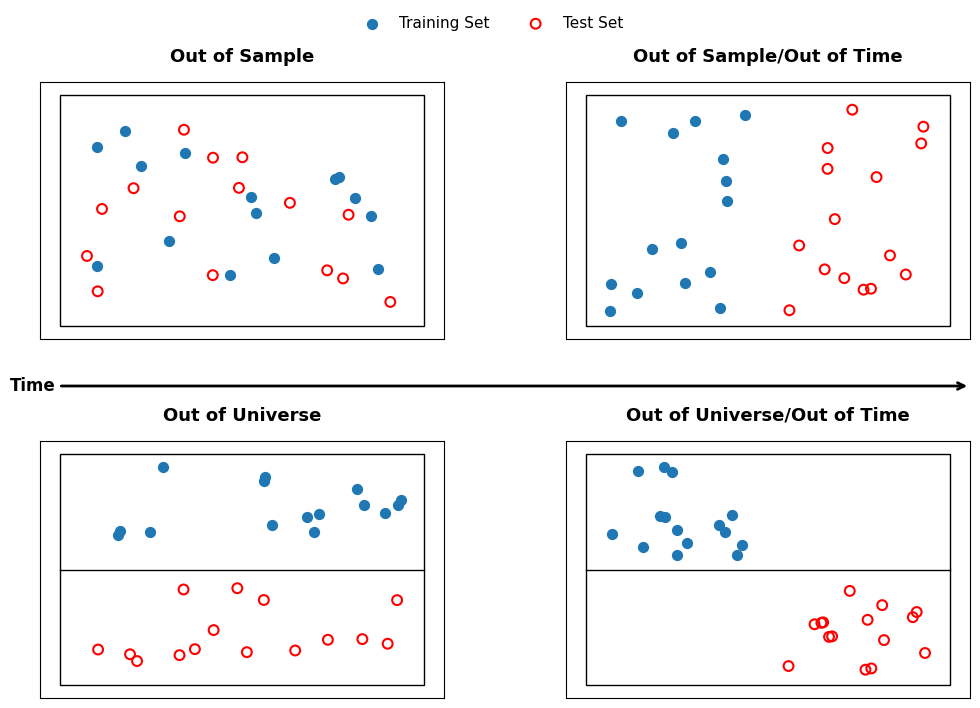

In [47]:
# Setup figure with more breathing room
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.subplots_adjust(wspace=0.3, hspace=0.4) # Add space between subplots

# Styling
train_style = {'marker': 'o', 'color': '#1f77b4', 'label': 'Training Set', 's': 50}
test_style = {'marker': 'o', 'facecolors': 'none', 'edgecolors': 'red', 'linewidth': 1.5, 'label': 'Test Set', 's': 50}
n_points = 15

def get_points(x_range, y_range, n):
    return np.random.uniform(*x_range, n), np.random.uniform(*y_range, n)

titles = [
    ["Out of Sample", "Out of Sample/Out of Time"],
    ["Out of Universe", "Out of Universe/Out of Time"]
]

for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(titles[i][j], pad=15, fontsize=13, fontweight='bold')
        
        # Internal bounding box
        rect = plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, color='black', linewidth=1)
        ax.add_patch(rect)

        if i == 0 and j == 0: # OOS
            xt, yt = get_points((0.1, 0.9), (0.1, 0.9), n_points)
            xv, yv = get_points((0.1, 0.9), (0.1, 0.9), n_points)
        elif i == 0 and j == 1: # OOS/OOT
            xt, yt = get_points((0.1, 0.45), (0.1, 0.9), n_points)
            xv, yv = get_points((0.55, 0.9), (0.1, 0.9), n_points)
        elif i == 1 and j == 0: # OOU
            ax.axhline(0.5, xmin=0.05, xmax=0.95, color='black', linewidth=1)
            xt, yt = get_points((0.1, 0.9), (0.55, 0.9), n_points)
            xv, yv = get_points((0.1, 0.9), (0.1, 0.45), n_points)
        elif i == 1 and j == 1: # OOU/OOT
            ax.axhline(0.5, xmin=0.05, xmax=0.95, color='black', linewidth=1)
            xt, yt = get_points((0.1, 0.45), (0.55, 0.9), n_points)
            xv, yv = get_points((0.55, 0.9), (0.1, 0.45), n_points)

        ax.scatter(xt, yt, **train_style)
        ax.scatter(xv, yv, **test_style)

# Add Legend at the very top
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=2, frameon=False, fontsize=11)

# Add the "Time" arrow across the middle
# Using fig.add_axes to create a transparent overlay for the arrow
arrow_ax = fig.add_axes([0.1, 0.48, 0.8, 0.04], frameon=False)
arrow_ax.set_xticks([]); arrow_ax.set_yticks([])
arrow_ax.annotate('Time', xy=(1, 0.5), xytext=(0, 0.5),
                  arrowprops=dict(arrowstyle="->", color='black', lw=2),
                  va='center', ha='left', fontsize=12, fontweight='bold')

plt.show()

#### Challenges in Quantitative Validation

The difference between predicted and observed default rates generally stems from three sources: **Sample Variability**, **External Macroeconomic Effects**, and **Internal Portfolio Shifts**.

Statistical significance requires large populations. To stay within a 20bps margin of error at a 95% confidence level for a 1% $PD$, the required sample size ($n$) is:
$$n = \left(\frac{1.96 \sqrt{PD(1-PD)}}{0.002}\right)^2 \approx 9,500 \text{ obligors}$$

* **Retail vs. Corporate:** Retail portfolios easily meet this threshold, but corporate portfolios often fall short, leading to high uncertainty in validation results. Because corporate portfolios have fewer obligors, the statistical "noise" is louder. This makes it harder to prove whether a model is failing or if the bank just had a few "unlucky" defaults.

Key statistical hurdles are:
* **Default Correlation:** The assumption that obligors are independent is usually false; defaults tend to cluster during economic downturns,which complicates the validation exercise and makes simple binomial models less reliable
* **Confidence Bounds:** Smaller samples result in wider confidence intervals, making it difficult to distinguish between a "bad model" and "bad luck."
* **Data Scarcity:** A lack of historical default data (especially in Low Default Portfolios) remains a fundamental challenge.

### Backtesting PD Models

We will follow the book and adopt a multilevel perspective on a PD model. The levels are as follows:

- Level 0: Stability (Population): Measures if the current population of borrowers is similar to the one used to build the model. This is primarily assessed using the Population Stability Index (PSI).

- Level 1: Discrimination: Evaluates how well the model ranks risk (e.g., do high-risk scores actually result in more defaults than low-risk scores?).

- Level 2: Calibration: Checks if the predicted PDs match the actual observed default rates.

We can also use, a traffic light system is used to interpret p-values from statistical tests:

- Green (p>0.10): Model is performing well.

- Yellow/Orange (0.01<p<0.10): Early warning; performance is decreasing.

- Red (p<0.01): Severe problem; immediate action/recalibration required.

#### Backtesting PD at Level 0

When validating stability at level 0, it's important to check whether internal or external environmental changes will impact the PD classification model. First we can use a population stability index (PSI) or system stability index, to indetify shifts in the distribution of scores or characteristics.

It's given as follows:

$$PSI = \sum_{k=1}^K (a_k - e_k) \times ln(\frac{a_k}{e_k})$$

where:

- PSI < 0.1: No significant shift.
- 0.1 - 0.25: Moderate shift (yellow)
- PSI > 0.25 - Significant shift (red)

In [48]:

data = {
    'score_range': range(1, 11),
    'expected': [0.06, 0.10, 0.09, 0.12, 0.12, 0.08, 0.07, 0.08, 0.12, 0.16],
    'actual':   [0.07, 0.08, 0.07, 0.09, 0.11, 0.11, 0.10, 0.12, 0.11, 0.15]
}

df = pd.DataFrame(data)

# Calculate PSI for each row
def calculate_psi(expected, actual):
    # Ensure no zeros to avoid division by zero or log(0)
    expected = np.where(expected == 0, 0.0001, expected)
    actual = np.where(actual == 0, 0.0001, actual)
    
    psi_values = (actual - expected) * np.log(actual / expected)
    return psi_values

df['psi_component'] = calculate_psi(df['expected'], df['actual'])
total_psi = df['psi_component'].sum()

print(f"Total PSI: {total_psi:.4f}")

# Interpretation
if total_psi < 0.1:
    print("Traffic Light: Green (No significant shift)")
elif total_psi < 0.25:
    print("Traffic Light: Yellow (Moderate shift)")
else:
    print("Traffic Light: Red (Significant shift)")

Total PSI: 0.0585
Traffic Light: Green (No significant shift)


It's also recommended to monitor the system stability index through time as below:

In [49]:
data = {
    'score':     np.arange(1, 11),
    'expected':  [0.06, 0.10, 0.09, 0.12, 0.12, 0.08, 0.07, 0.08, 0.12, 0.16],
    'actual_t':  [0.07, 0.08, 0.07, 0.09, 0.11, 0.11, 0.10, 0.12, 0.11, 0.15],
    'actual_t1': [0.06, 0.07, 0.10, 0.11, 0.10, 0.09, 0.11, 0.11, 0.10, 0.15]
}

df = pd.DataFrame(data)

# PSI_e0: Expected (Training) vs Observed at time t
df['psi_row_e0'] = calculate_psi(df['expected'], df['actual_t'])
psi_e0 = df['psi_row_e0'].sum()

# PSI_e1: Expected (Training) vs Observed at time t+1
df['psi_row_e1'] = calculate_psi(df['expected'], df['actual_t1'])
psi_e1 = df['psi_row_e1'].sum()

# PSI_t: Observed at t vs Observed at t+1 (System Stability Index)
df['psi_row_t'] = calculate_psi(df['actual_t'], df['actual_t1'])
psi_t = df['psi_row_t'].sum()

print(f"PSI (Training vs t):     {psi_e0:.4f}")
print(f"PSI (Training vs t+1):   {psi_e1:.4f}")
print(f"PSI (t vs t+1):          {psi_t:.4f}")

# 5. Traffic Light Logic (from Exhibit 13.6)
def traffic_light(psi_val):
    if psi_val < 0.10: return "Green (Stable)"
    if 0.10 <= psi_val < 0.25: return "Yellow (Moderate Shift)"
    return "Red (Significant Shift)"

print(f"\nStatus (Training vs t+1): {traffic_light(psi_e1)}")

PSI (Training vs t):     0.0585
PSI (Training vs t+1):   0.0494
PSI (t vs t+1):          0.0253

Status (Training vs t+1): Green (Stable)


This allows us to see the evolution of the PSI through time and detect when important changes occur. In PIT rating systems, obligors will ceteris paribus be upgraded in an economic upswing and therefore obligors will move into the upper rating grades, whereas the opposite might happen in a downswing. Thus, you have to be caresul in diagnosing the reason for instabilities.

When population instability has been diagnosed, you can then verify the stability of the individual variables. Again, a PSI can be calculated at the variable level, as displayed below, in python.

In [50]:
def get_variable_psi(expected_probs, actual_probs, bin_names):
    expected = np.array(expected_probs)
    actual = np.array(actual_probs)
    
    # Calculate components
    # Using np.clip to avoid log(0) or division by zero
    actual_adj = np.clip(actual, 0.0001, 1)
    expected_adj = np.clip(expected, 0.0001, 1)
    
    psi_values = (actual_adj - expected_adj) * np.log(actual_adj / expected_adj)
    
    df_res = pd.DataFrame({
        'Bin': bin_names,
        'Expected %': expected * 100,
        'Actual %': actual * 100,
        'PSI Component': psi_values
    })
    
    total_psi = df_res['PSI Component'].sum()
    
    # Traffic Light Logic
    if total_psi < 0.10:
        status = "Green (Stable)"
    elif total_psi < 0.25:
        status = "Yellow (Moderate Shift)"
    else:
        status = "Red (Significant Shift)"
        
    return total_psi, status, df_res

# Example execution for "Years as Client"
bins = ['0-2 yrs', '2-5 yrs', '5-10 yrs', '10+ yrs']
exp = [0.20, 0.30, 0.40, 0.10]
act = [0.25, 0.30, 0.30, 0.15]

psi_val, status, table = get_variable_psi(exp, act, bins)

print(f"Variable PSI: {psi_val:.4f}")
print(f"Status: {status}")
print("\nBreakdown:")
print(table)

Variable PSI: 0.0602
Status: Green (Stable)

Breakdown:
        Bin  Expected %  Actual %  PSI Component
0   0-2 yrs        20.0      25.0       0.011157
1   2-5 yrs        30.0      30.0       0.000000
2  5-10 yrs        40.0      30.0       0.028768
3   10+ yrs        10.0      15.0       0.020273


Another way of testing stability of a PD model is to include dummy variables for the in-sample and out-of-sample periods in a logistic regression model and test wheter the dummies and time interactions are statistically significant. This approach is a powerful way to test if your model coefficients are "drifting" over time. If the interaction terms (the ones where the dummy variable is multiplied by your features) are statistically significant, it means the impact of that variable on default risk has changed between the two time periods.

Optimization terminated successfully.
         Current function value: 0.110503
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:           default_time   No. Observations:               622489
Model:                         Probit   Df Residuals:                   622482
Method:                           MLE   Df Model:                            6
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                 0.03507
Time:                        09:27:58   Log-Likelihood:                -68787.
converged:                       True   LL-Null:                       -71287.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -1.0884      0.046    -23.647      0.000      -1.

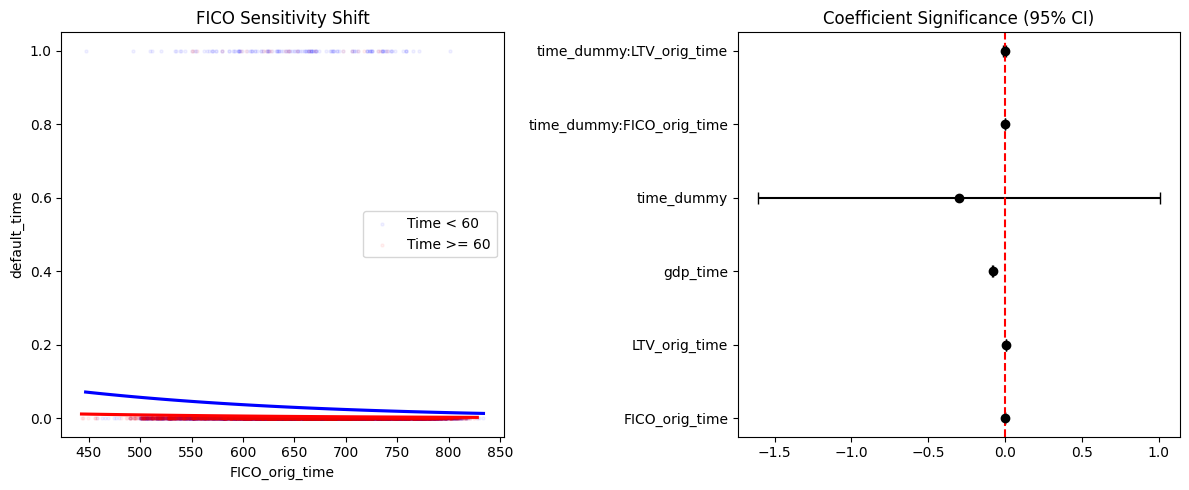

In [51]:
mortgage['time_dummy'] = np.where(mortgage['time'] < 60, 0, 1)

# We include the interaction terms using the ':' operator
formula = """
default_time ~ FICO_orig_time + LTV_orig_time + gdp_time + 
               time_dummy + 
               time_dummy:FICO_orig_time + 
               time_dummy:LTV_orig_time
"""

model = smf.probit(formula, data=mortgage).fit()
print(model.summary())

# Testing if 'time_dummy' and its interactions are JOINTLY zero
# If p-value < 0.05, the model is unstable over time.
hypotheses = '(time_dummy = 0), (time_dummy:FICO_orig_time = 0), (time_dummy:LTV_orig_time = 0)'
wald_test = model.wald_test(hypotheses)
print(f"\nJoint Wald Test P-Value: {wald_test.pvalue:.4f}")

MAX_PLOT = 5000

t0 = mortgage[mortgage['time_dummy'] == 0]
t1 = mortgage[mortgage['time_dummy'] == 1]

t0_sample = t0.sample(min(MAX_PLOT, len(t0)), random_state=42)
t1_sample = t1.sample(min(MAX_PLOT, len(t1)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
sns.regplot(
    x='FICO_orig_time', y='default_time',
    data=t0_sample,
    logistic=True,
    ci=None,                              # removes slow bootstrapped CI band
    scatter_kws={'alpha': 0.05, 's': 5},
    label='Time < 60',
    color='blue',
    ax=ax1
)
sns.regplot(
    x='FICO_orig_time', y='default_time',
    data=t1_sample,
    logistic=True,
    ci=None,
    scatter_kws={'alpha': 0.05, 's': 5},
    label='Time >= 60',
    color='red',
    ax=ax1
)
ax1.set_title('FICO Sensitivity Shift')
ax1.legend()

ax2 = axes[1]
coef_df = model.params.to_frame('coef')
coef_df['error'] = model.bse
coef_df = coef_df.drop('Intercept')

ax2.errorbar(
    coef_df['coef'], coef_df.index,
    xerr=coef_df['error'] * 1.96,
    fmt='o', color='black', capsize=4
)
ax2.axvline(0, color='red', linestyle='--')
ax2.set_title('Coefficient Significance (95% CI)')

plt.tight_layout()
plt.show()

All three base predictors have p < 0.001 and signs in the expected direction — the model is fundamentally well-specified. All three interaction dummy terms are individually insignificant (p >> 0.05). This means neither the level of default risk nor the sensitivity to FICO/LTV changed meaningfully after period 60.

The Wald test gives us a seemingly contradictory result. Even though all three dummies are individually insignificant, the joint test rejects stability at p < 0.0001.
This happens because the Wald test picks up collinearity-driven joint effects — the three variables together explain a statistically detectable shift even if no single one does alone. In practical validation terms this means: "The model is jointly unstable over time, even if you can't pinpoint which specific coefficient drove the change."

### Backtesting PD at Level 1

Now we validate the discriminatory power of a scorecard or PD model. Level 1 focuses on the model's ability to rank risk. A model with high discriminatory power will cluster future defaulters into high-risk categories (low scores) and non-defaulters into low-risk categories (high scores).

Before analyzing performance curves, a qualitative and statistical review of the model's "health" is required:
* **Coefficient Intuition:** Verify that the signs of the regression coefficients align with economic reality (e.g., a higher debt ratio should lead to a higher $PD$).
* **Significance:** Review $p$-values and model-wide significance tests.
* **Multicollinearity:** Check Variance Inflation Factors (VIF) to ensure independent variables aren't overly correlated.
* **Data Quality:** Confirm the appropriateness of outlier handling, missing value treatments, and coarse classification (binning).

Then we use key performance metrics.

| Metric | Definition | Interpretation |
| :--- | :--- | :--- |
| **ROC Curve** | Plots Hit Rate (Sensitivity) vs. False Alarm Rate (1-Specificity). | A curve bowing toward the top-left indicates better performance. |
| **AUROC (AUC)** | The Area Under the ROC Curve. | 0.5 is random; 1.0 is a perfect classifier. |
| **CAP Curve** | Cumulative % of defaulters vs. cumulative % of total population. | Also known as the Gini or Power curve. |
| **Accuracy Ratio (AR)** | Ratio of the area under the real CAP vs. the ideal CAP. | Ranges from 0 (random) to 1 (perfect). |

Both frameworks provide identical information. The Accuracy Ratio ($AR$) is a linear transformation of the $AUROC$:
$$AR = 2(AUROC - 0.5)$$

In [52]:
tmp_pdvali1 = mortgage[mortgage['time'] < 60].copy()
tmp_pdvali2 = mortgage[mortgage['time'] > 59].copy()
tmp_pdvali1 = tmp_pdvali1.sort_values(by=['id', 'time'])
tmp_pdvali2 = tmp_pdvali2.sort_values(by=['id', 'time'])

# Reset index is often a good idea after filtering/sorting in pandas
tmp_pdvali1 = tmp_pdvali1.reset_index(drop=True)
tmp_pdvali2 = tmp_pdvali2.reset_index(drop=True)

# Verification
print(f"In-Sample Records: {len(tmp_pdvali1)}")
print(f"Out-of-Time Records: {len(tmp_pdvali2)}")

In-Sample Records: 614485
Out-of-Time Records: 8004


Optimization terminated successfully.
         Current function value: 0.114889
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.113617
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.111515
         Iterations 7


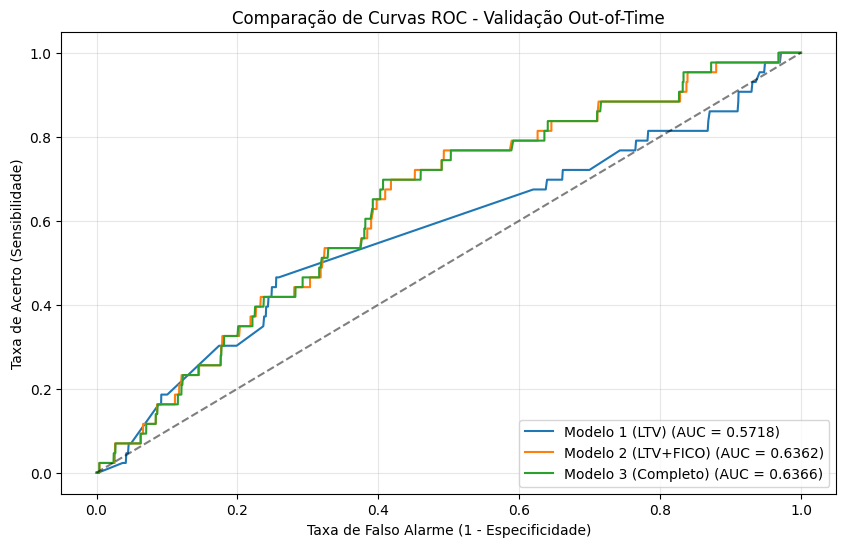

In [53]:
# Model 1: Apenas LTV
m1 = smf.probit("default_time ~ LTV_orig_time", data=tmp_pdvali1).fit()
# Model 2: LTV + FICO
m2 = smf.probit("default_time ~ LTV_orig_time + FICO_orig_time", data=tmp_pdvali1).fit()
# Model 3: LTV + FICO + GDP
m3 = smf.probit("default_time ~ LTV_orig_time + FICO_orig_time + gdp_time", data=tmp_pdvali1).fit()
pred = tmp_pdvali2[['id', 'time', 'default_time']].copy()
pred['prob1'] = m1.predict(tmp_pdvali2)
pred['prob2'] = m2.predict(tmp_pdvali2)
pred['prob3'] = m3.predict(tmp_pdvali2)
from scipy.stats import norm
pred['xbeta1'] = norm.ppf(pred['prob1'].clip(1e-5, 1-1e-5))
pred['xbeta2'] = norm.ppf(pred['prob2'].clip(1e-5, 1-1e-5))
pred['xbeta3'] = norm.ppf(pred['prob3'].clip(1e-5, 1-1e-5))
plt.figure(figsize=(10, 6))
models = [('Modelo 1 (LTV)', 'prob1'), 
          ('Modelo 2 (LTV+FICO)', 'prob2'), 
          ('Modelo 3 (Completo)', 'prob3')]
for label, col in models:
    fpr, tpr, _ = roc_curve(pred['default_time'], pred[col])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('Taxa de Falso Alarme (1 - Especificidade)')
plt.ylabel('Taxa de Acerto (Sensibilidade)')
plt.title('Comparação de Curvas ROC - Validação Out-of-Time')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [54]:
def compare_auc_bootstrap(y_true, prob_a, prob_b, n_iterations=1000, alpha=0.05):
    """
    Statistically compares the AUC of two models using the Bootstrap method.
    Returns the mean difference, confidence interval, and p-value.
    """
    auc_differences = []
    
    # Convert to numpy to ensure correct indexing
    y_true = np.array(y_true)
    prob_a = np.array(prob_a)
    prob_b = np.array(prob_b)
    
    print(f"Starting {n_iterations} bootstrap iterations...")
    
    for i in range(n_iterations):
        # Resampling with replacement (Bootstrap)
        indices = resample(np.arange(len(y_true)), replace=True)
        
        # Check to avoid error if the sample contains only one class
        if len(np.unique(y_true[indices])) < 2:
            continue
            
        auc_a = roc_auc_score(y_true[indices], prob_a[indices])
        auc_b = roc_auc_score(y_true[indices], prob_b[indices])
        
        auc_differences.append(auc_b - auc_a)
        
    # Statistics
    diff_array = np.array(auc_differences)
    mean_diff = np.mean(diff_array)
    std_diff = np.std(diff_array)
    
    # Confidence Interval (Percentile method)
    lower = np.percentile(diff_array, (alpha/2)*100)
    upper = np.percentile(diff_array, (1 - alpha/2)*100)
    
    # P-value (Approximate Z-test)
    z_score = mean_diff / std_diff
    p_value = stats.norm.sf(abs(z_score)) * 2 # two-sided
    
    return {
        'mean_diff': mean_diff,
        'conf_interval': (lower, upper),
        'p_value': p_value,
        'significant': lower > 0 or upper < 0
    }

# Comparing Model 1 (LTV) with Model 3 (Full) from your exercise
result = compare_auc_bootstrap(pred['default_time'], pred['prob1'], pred['prob3'])

print("-" * 30)
print(f"Mean AUC Difference: {result['mean_diff']:.4f}")
print(f"95% Confidence Interval: [{result['conf_interval'][0]:.4f}, {result['conf_interval'][1]:.4f}]")
print(f"P-value: {result['p_value']:.4f}")
print(f"Statistically Significant Improvement? {'YES' if result['significant'] else 'NO'}")

Starting 1000 bootstrap iterations...
------------------------------
Mean AUC Difference: 0.0639
95% Confidence Interval: [-0.0099, 0.1397]
P-value: 0.0960
Statistically Significant Improvement? NO


* **Model 1 (LTV - Blue):** With an AUC of **0.5718**, this model is very weak. It sits almost on the diagonal dotted line (which represents pure random chance). In credit risk modeling, any model with an AUC below **0.60** is typically considered insufficient.
* **Model 2 (LTV + FICO - Orange):** There was a significant jump to **0.6362**. FICO clearly added substantial predictive power to the framework.
* **Model 3 (Complete - Green):** The AUC rose slightly to **0.6366**. In other words, adding GDP practically changed nothing, yielding a gain of only **0.0004**.

Even though the average AUC difference is **0.0656** (which seems high visually), the test indicates that the improvement is **NOT** statistically significant.

* **95% Confidence Interval [-0.0134, 0.1364]:** This is the most critical finding. Because the interval starts at a negative value and ends at a positive one, it crosses **ZERO**. This means that, statistically, there is a chance the true difference is zero, or even that the simpler model could outperform the complex one in different scenarios.
* **P-value (0.0945):** Since the p-value is greater than **0.05** (the standard industry threshold), you lack sufficient evidence to reject the null hypothesis that the models are equivalent.

* **LTV alone is insufficient:** Model 1 provides poor discrimination between defaulters and non-defaulters.
* **FICO is the driver:** The vast majority of the performance gain is derived from the FICO variable (Model 2).
* **GDP is noise:** For this specific Out-of-Time validation set, GDP provided no real added benefit.
* **Statistical Inconclusiveness:** Despite the visual improvement on the ROC chart, the Bootstrap test suggests caution. With a p-value of **0.09**, you are in a "gray area." In a rigorous audit, it could be argued that it hasn't been proven that the more complex model is superior to the simpler one.

> **Note:** This result is likely due to the small size of the validation dataset (`pred2`). With limited data, confidence intervals become very wide, making it difficult to statistically prove that one model is better than another.

### Backtesting PD at Level 2

Level 2 of the validation architecture focuses on **Calibration**, which refers to the accuracy of the estimated Probabilities of Default ($PD$). While discrimination (Level 1) evaluates the risk ranking, calibration ensures that the absolute $PD$ values reflect reality. Calibration is often considered the most critical level because the resulting $PDs$ are used directly to calculate **regulatory capital requirements**.

**Key questions for validation:**
* Do the ratings properly reflect the obligor’s default risk?
* Are the credit characteristics of obligors in the same rating sufficiently **homogeneous**?
* Is there enough **granularity** (number of ratings) to allow for an accurate and consistent estimation?
* Are the estimated $PDs$ (*ex ante*) in line with the observed default rates (*ex post*)?


We should also verify:
* **Ordinal Measure:** Verifies if the default rates ($DR$) follow the correct order of the ratings. Example: $DR(A) < DR(B) < DR(C)$.
* **Cardinal Measure:** Ensures that the calibrated $PD$ is as close as possible to the realized default rate.

At level 0 we used PSI, at level 1, AR, now at level 2, we use the Brier Score, that is a mean squared error metric used to evaluate the accuracy of probabilistic predictions.

$$BS = \frac{1}{n} \sum_{i=1}^{n} (\hat{\pi}_i - d_i)^2$$

Where:
* $\hat{\pi}_i$: Estimated Probability of Default for obligor $i$.
* $d_i$: Observed outcome (1 for default, 0 for non-default).


The value ranges between **0 and 1**, the **lower** the value, the better the model's calibration and discrimination. Lower values indicate that the estimates are closer to the actual results.

In [55]:
cols_to_keep = ['default_time', 'prob1', 'prob2', 'prob3']
brier_df = pred[cols_to_keep].copy()
bs1 = brier_score_loss(brier_df['default_time'], brier_df['prob1'])
bs2 = brier_score_loss(brier_df['default_time'], brier_df['prob2'])
bs3 = brier_score_loss(brier_df['default_time'], brier_df['prob3'])

# (data[,2]-data[,1])##2 -> squared differences
# [+]/NROW(data)        -> mean
manual_bs1 = ((brier_df['prob1'] - brier_df['default_time'])**2).mean()
manual_bs2 = ((brier_df['prob2'] - brier_df['default_time'])**2).mean()
manual_bs3 = ((brier_df['prob3'] - brier_df['default_time'])**2).mean()

# 4. Display Results
print(f"Brier Score Model 1: {bs1:.6f}")
print(f"Brier Score Model 2: {bs2:.6f}")
print(f"Brier Score Model 3: {bs3:.6f}")

Brier Score Model 1: 0.005725
Brier Score Model 2: 0.005774
Brier Score Model 3: 0.005524


As the values show, the best model is given by model 3.

Since defaults are typically correlated and samples can be small, various other tests are used as early warning indicators:
* **Binomial Test**
* **Hosmer-Lemeshow Test**
* **Vasicek (ASRF) One-Factor Model**
* **Normal Test**

Let's go through some of these.

#### Binomial

The Binomial Test is a fundamental tool for checking if the realized default rates in a portfolio are consistent with the model's predicted Probability of Default ($\pi_0$).

The test assumes:
1. **Binary outcomes** (Default/Non-default).
2. **Identical probabilities** for all obligors in a grade.
3. **Independence** between obligors.

> **Note:** Because defaults are often correlated in the real world, the independence assumption is rarely fully met. Therefore, the test is treated as a conservative heuristic or early-warning signal for potential underestimation of risk.

The hypothesis test is given by:
* **$H_0$:** The predicted PD ($\pi_0$) is accurate.
* **$H_1$:** The true PD is higher than predicted ($\pi > \pi_0$).

When the sample size $n$ is large, we use the **Normal Approximation** to calculate the critical threshold ($p^*$) for the observed default rate at a significance level $\alpha$:

$$p^* = \Phi^{-1}(\alpha) \sqrt{\frac{\pi_0(1-\pi_0)}{n}} + \pi_0$$

If the actual observed default rate is higher than $p^*$, the null hypothesis is rejected, indicating the model is likely under-predicting risk for that grade.

In [56]:
def apply_fico_bins(df):
    # 1. Define conditions
    conditions = [
        (df['FICO_orig_time'] >= 713),
        (df['FICO_orig_time'] >= 648) & (df['FICO_orig_time'] < 713),
        (df['FICO_orig_time'] < 648)
    ]
    
    # 2. Define choices corresponding to conditions
    choices = [1, 2, 3]
    
    # 3. Create the new column (default=0 as in your SAS code)
    df['fico_class'] = np.select(conditions, choices, default=0)
    return df

# Apply to your two datasets
fico_class1 = apply_fico_bins(tmp_pdvali1.copy())
fico_class2 = apply_fico_bins(tmp_pdvali2.copy())

# Display sample to verify
print(fico_class1[['FICO_orig_time', 'fico_class']].head())

   FICO_orig_time  fico_class
0             715           1
1             715           1
2             715           1
3             715           1
4             715           1


In [57]:
ct = pd.crosstab(fico_class1['fico_class'], 
                 fico_class1['default_time'], 
                 margins=True,            # Adds the "Total" row and column
                 margins_name="Total")    # Names the total column/row
print("Frequency Table: FICO Class vs. Default")
ct['Observed_DR'] = ct[1] / ct['Total']

print(ct[['Total', 1, 'Observed_DR']])

Frequency Table: FICO Class vs. Default
default_time   Total      1  Observed_DR
fico_class                              
1             196632   2694     0.013701
2             204432   5189     0.025383
3             213421   7232     0.033886
Total         614485  15115     0.024598


In [58]:
fico_class2 = fico_class2.sort_values(by='fico_class')
results = []
target_pd = 0.01
alpha = 0.05

# Group by 'fico_class' and iterate
for name, group in fico_class2.groupby('fico_class'):
    n = len(group)
    k = group['default_time'].sum()  # Count of defaults (assuming 1=default)
    observed_dr = k / n
    
    # scipy.stats.binomtest returns the exact p-value
    # alternative='greater' tests if DR > target_pd (Basel standard)
    test_result = stats.binomtest(k, n, p=target_pd, alternative='greater')
    
    results.append({
        'FICO Class': name,
        'Count (n)': n,
        'Defaults (k)': k,
        'Observed DR': observed_dr,
        'P-Value': test_result.pvalue,
        'Reject H0?': 'YES' if test_result.pvalue < alpha else 'NO'
    })

# Convert to DataFrame for a clean summary
summary_df = pd.DataFrame(results)
print(summary_df)

   FICO Class  Count (n)  Defaults (k)  Observed DR   P-Value Reject H0?
0           1       2481             7     0.002821  0.999993         NO
1           2       2592            10     0.003858  0.999887         NO
2           3       2931            26     0.008871  0.755585         NO


By these results, we should not reject the null hypothesis that the model is accurate. Meaning, the model is statistically safe and is not underestimating risk.

#### Hosmer-Lemeshow (HL) Statistic

The HL Statistic provides a **Global Calibration** check, testing all rating grades simultaneously rather than on a grade-by-grade basis.

Observations are sorted by estimated $PD$ and partitioned into $G$ groups (usually 10). The test then calculates the squared difference between observed defaults ($O_g$) and expected defaults ($n_g\hat{\pi}_g$), normalized by the variance.

$$\chi^2_{HL} = \sum_{g=1}^{G} \frac{(O_g - n_g \hat{\pi}_g)^2}{n_g \hat{\pi}_g (1 - \hat{\pi}_g)}$$

* **Null Hypothesis ($H_0$):** The model is well-calibrated (Predicted $\approx$ Observed).
* **High $\chi^2$ / Low P-Value:** Reject $H_0$. This indicates a "Lack of Fit," meaning the model significantly misrepresents the actual default rates across the distribution.
* **Distribution:** The statistic follows a $\chi^2$ (Chi-square) distribution with $G - 2$ degrees of freedom.
* **The "Lack of Fit" Signal:** Unlike many statistical tests where a high value is desirable, in the HL test, **large values are problematic**.
    * A **high $\chi^2$** value (resulting in a small **$p$-value**, typically $< 0.05$) indicates a **lack of fit**. 
    * This means the model's predicted probabilities deviate significantly from the actual observed default behavior across the different risk deciles.
* **Validation Goal:** For a "Pass," you are looking for a **low $\chi^2$** and a **high $p$-value** ($p > 0.05$), suggesting that there is no statistically significant difference between your predicted PDs and the realized default rates.

Hosmer-Lemeshow Statistic: 72.3201
P-Value: 0.0000

LackFit Partition Table (Observed vs Expected):
         n  observed  avg_prob   expected
group                                    
0      801         1  0.007585   6.075957
1      803         4  0.009827   7.890795
2      798         2  0.011566   9.229566
3      811         2  0.013302  10.787913
4      789         2  0.015090  11.905655
5      800         4  0.017077  13.661754
6      801         8  0.019387  15.529289
7      800         6  0.022386  17.908938
8      803         7  0.026577  21.341541
9      798         7  0.034783  27.757169


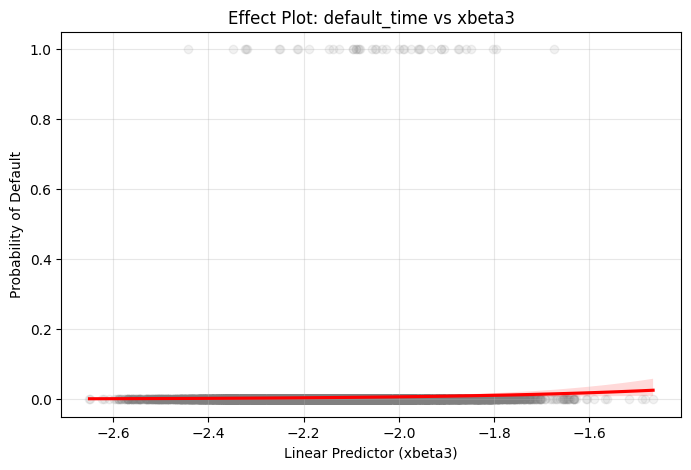

In [59]:
def hosmer_lemeshow_test(y_true, y_prob, groups=10):
    data = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob})
    
    data['group'] = pd.qcut(data['y_prob'], groups, labels=False, duplicates='drop')
    
    hl_table = data.groupby('group').agg(
        n=('y_true', 'count'),
        observed=('y_true', 'sum'),
        avg_prob=('y_prob', 'mean')
    )
    hl_table['expected'] = hl_table['n'] * hl_table['avg_prob']
    
    # Formula: sum( (O - E)^2 / (E * (1 - pi)) )
    num = (hl_table['observed'] - hl_table['expected'])**2
    den = hl_table['expected'] * (1 - hl_table['avg_prob'])
    hl_stat = (num / den).sum()
    
    df = len(hl_table) - 2
    p_value = 1 - stats.chi2.cdf(hl_stat, df)
    
    return hl_stat, p_value, hl_table

hl_stat, p_val, partition_table = hosmer_lemeshow_test(pred['default_time'], pred['prob3'])

print(f"Hosmer-Lemeshow Statistic: {hl_stat:.4f}")
print(f"P-Value: {p_val:.4f}")
print("\nLackFit Partition Table (Observed vs Expected):")
print(partition_table)

plt.figure(figsize=(8, 5))
sns.regplot(x='xbeta3', y='default_time', data=pred, logistic=True, 
            scatter_kws={'alpha':0.1, 'color':'gray'}, line_kws={'color':'red'})
plt.title('Effect Plot: default_time vs xbeta3')
plt.xlabel('Linear Predictor (xbeta3)')
plt.ylabel('Probability of Default')
plt.grid(alpha=0.3)
plt.show()

The red logistic curve is hugging the bottom of the graph. This confirms that defaults are rare events in the dataset. However, because the grey dots at y=1 (actual defaults) are so sparse compared to the dense cloud at y=0, the red line should actually be even lower to fit the data perfectly.

In [60]:
calibration = partition_table.copy()
calibration['obs_freq'] = calibration['observed'] / calibration['n']
calibration['exp_freq'] = calibration['expected'] / calibration['n']
calibration_summary = calibration[['n', 'obs_freq', 'exp_freq']]

print("Calibration Data (Observed vs. Expected Rates):")
print(calibration_summary)

Calibration Data (Observed vs. Expected Rates):
         n  obs_freq  exp_freq
group                         
0      801  0.001248  0.007585
1      803  0.004981  0.009827
2      798  0.002506  0.011566
3      811  0.002466  0.013302
4      789  0.002535  0.015090
5      800  0.005000  0.017077
6      801  0.009988  0.019387
7      800  0.007500  0.022386
8      803  0.008717  0.026577
9      798  0.008772  0.034783


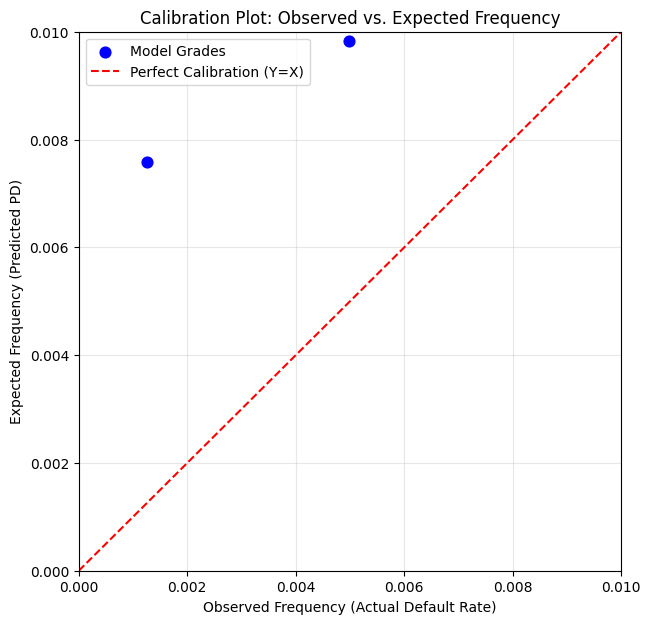

In [61]:

plt.figure(figsize=(7, 7))
plt.scatter(calibration['obs_freq'], calibration['exp_freq'], 
            color='blue', marker='o', edgecolors='blue', s=60, label='Model Grades')

plt.plot([0, 0.01], [0, 0.01], color='red', linestyle='--', label='Perfect Calibration (Y=X)')
ticks = np.arange(0, 0.012, 0.002)
plt.xlim(0, 0.01)
plt.ylim(0, 0.01)
plt.xticks(ticks)
plt.yticks(ticks)

plt.xlabel('Observed Frequency (Actual Default Rate)')
plt.ylabel('Expected Frequency (Predicted PD)')
plt.title('Calibration Plot: Observed vs. Expected Frequency')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

This is the most important visual. The blue dots are way above the red dashed line.

- Dots above the line: Indicate Over-prediction (Pessimism).

- Dots on the line: Indicate Perfect Calibration.

- Dots below the line: Indicate Under-prediction (Optimism/Risk).


There are usually two reasons for this specific pattern:

- Low Default Portfolio (LDP): You have very few "events" (defaults). Logistic regression naturally struggles to calibrate correctly when the target class is this rare.

- Model Drift / Data Shift: The model was likely trained on a "stressed" period (like a recession) where defaults were high, but you are now validating it on a "benign" period where defaults have dropped.

#### Binomial Test with Correlation (Vasicek Model)

This advanced calibration test addresses the "Real-World" problem of **Default Correlation**. Standard binomial tests assume that one borrower's default does not affect another; however, in practice, defaults often cluster during economic downturns.

When defaults are correlated, the probability distribution of the number of defaults becomes **wider**, featuring "fat tails." 
* **The Risk:** If you use a standard (uncorrelated) test, you might mistakenly reject a well-calibrated model just because a systematic economic shock caused a temporary spike in defaults.

To account for this, we use the **Basel one-factor model**. It assumes a systematic factor ($X$)—representing the state of the economy—influences all obligors simultaneously.

**The Unconditional Probability Distribution:**
$$P(D = d) = \int_{-\infty}^{\infty} \binom{n}{d} CPD(x)^d (1 - CPD(x))^{n-d} \phi(x)dx$$

**The Conditional Probability of Default ($CPD$):**
$$CPD(X) = \Phi \left( \frac{c - \sqrt{\rho}X}{\sqrt{1 - \rho}} \right)$$

*Where:*
* **$c = \Phi^{-1}(PD)$**: The default threshold.
* **$\rho$ (Rho)**: The asset correlation, representing how sensitive the portfolio is to the general economy.
* **$X = \Phi^{-1}(\alpha)$:  The systematic factor


* **Critical Values:** As correlation ($\rho$) increases, the critical values required to reject the Null Hypothesis ($H_0$) increase sharply.
* **Validation Strategy:** By incorporating correlation, the test becomes more "tolerant" of high default counts during systemic stress. This prevents the model from being unfairly penalized for macro-economic events that are outside the scope of its specific rating logic.
* **Decision Rule:** $H_0$ is rejected if the observed default rate exceeds the quantile calculated via this wider distribution at a specific significance level (e.g., $\alpha = 0.99$).

Computing quantiles for N=100...


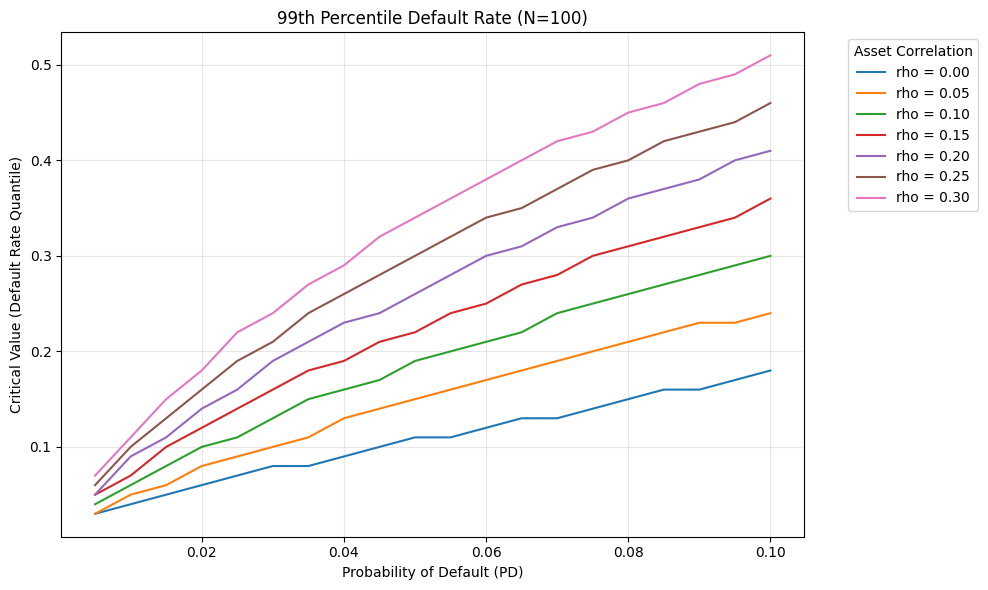

In [62]:
N = 100
rhos = np.arange(0, 0.35, 0.05)
pds = np.arange(0.005, 0.105, 0.005)
target_quantile = 0.99
results = []

def vasicek_cdf(k, n, prob_default, rho):
    if rho == 0:
        return binom.cdf(k, n, prob_default)
    
    c = norm.ppf(prob_default)
    
    def integrand(x):
        cpd_x = norm.cdf((c - np.sqrt(rho) * x) / np.sqrt(1 - rho))
        return binom.cdf(k, n, cpd_x) * norm.pdf(x)
    
    val, _ = quad(integrand, -8, 8)
    return val

print(f"Computing quantiles for N={N}...")
for rho in rhos:
    for prob_default in pds:         
        k_quantile = 0
        for k in range(N + 1):
            prob = vasicek_cdf(k, N, prob_default, rho)
            if prob >= target_quantile:
                k_quantile = k
                break
        
        results.append({
            'rho': rho,
            'pd': prob_default,       
            'quantile_k': k_quantile,
            'critical_value': k_quantile / N
        })

df = pd.DataFrame(results)           

plt.figure(figsize=(10, 6))
for rho in rhos:
    subset = df[df['rho'] == rho]
    plt.plot(subset['pd'], subset['critical_value'], label=f'rho = {rho:.2f}')

plt.title(f'99th Percentile Default Rate (N={N})')
plt.xlabel('Probability of Default (PD)')
plt.ylabel('Critical Value (Default Rate Quantile)')
plt.legend(title='Asset Correlation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

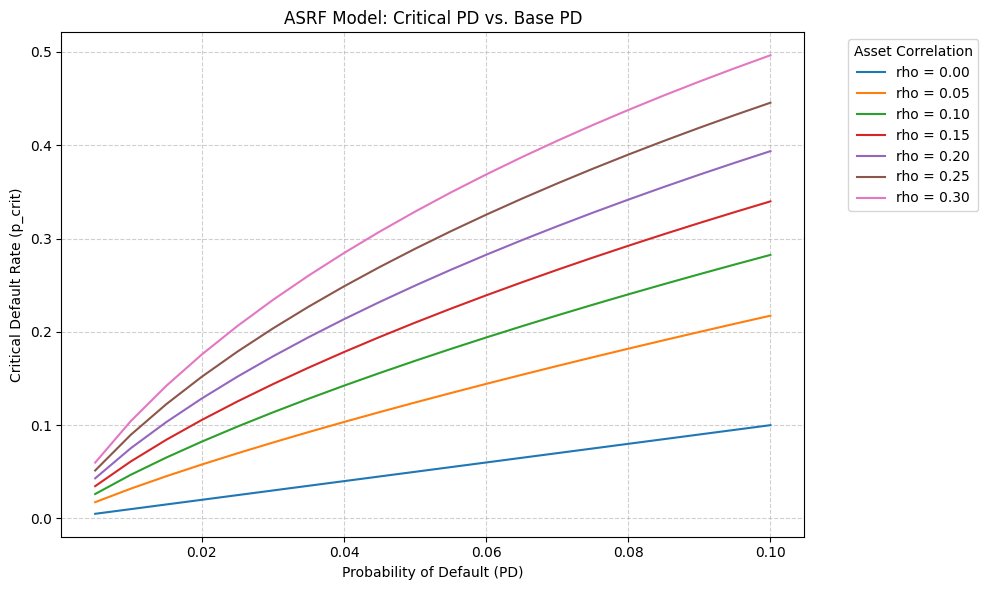

In [63]:
pd_range = np.arange(0.005, 0.105, 0.005)
rho_range = np.arange(0, 0.35, 0.05)
confidence_level = 0.99
results = []

for rho in rho_range:
    for prob_default in pd_range:          # <-- renamed from 'pd'
        z_pd = stats.norm.ppf(prob_default)
        z_alpha = stats.norm.ppf(confidence_level)
        
        if rho < 1:
            numerator = z_pd + np.sqrt(rho) * z_alpha
            denominator = np.sqrt(1 - rho)
            p_crit = stats.norm.cdf(numerator / denominator)
        else:
            p_crit = 1.0
            
        results.append({'PD': prob_default, 'rho': rho, 'p_crit': p_crit})  # <-- updated

asrf_crit = pd.DataFrame(results)          # <-- pd now refers to pandas again

plt.figure(figsize=(10, 6))
for rho in rho_range:
    subset = asrf_crit[asrf_crit['rho'] == rho]
    plt.plot(subset['PD'], subset['p_crit'], label=f'rho = {rho:.2f}')

plt.title('ASRF Model: Critical PD vs. Base PD')
plt.xlabel('Probability of Default (PD)')
plt.ylabel('Critical Default Rate (p_crit)')
plt.legend(title='Asset Correlation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

These two scripts represent the same fundamental financial concept—the **Vasicek Model** for credit risk—but they approach it from two different mathematical perspectives: **Discrete (Finite)** vs. **Continuous (Infinite)**.

| Feature | **Code 1: Vasicek Numerical (Finite $N=100$)** | **Code 2: ASRF Model (Infinite $N$)** |
| :--- | :--- | :--- |
| **Portfolio Size** | Assumes a small, finite portfolio ($N=100$). | Assumes an "Asymptotic" (infinite) portfolio. |
| **Math Approach** | **Numerical Integration:** Uses `quad` to integrate the Binomial distribution. | **Closed-form Formula:** Uses a single Normal CDF equation. |
| **Output Type** | **Discrete:** You can only have a whole number of defaults (e.g., 5 or 6). | **Continuous:** The default rate can be any decimal value. |
| **Visual Appearance** | **Jagged/Stepped:** The lines have "teeth" or small jumps. | **Smooth:** The lines are perfect, elegant curves. |


#### **Plot 1: The "Jagged" Truth (Finite $N$)**
Look closely at the lines in the first plot. You’ll notice they aren't perfectly smooth; they have tiny vertical jumps.
* **Why?** Because with only 100 people, the 99th percentile must be an integer (e.g., 12 defaults out of 100). As you increase the PD slightly, the math might still result in "12 defaults" until it hits a specific threshold where it suddenly jumps to "13."
* **Reality Check:** This is more realistic for a small bank or a specific loan desk with a limited number of clients.

#### **Plot 2: The "Smooth" Ideal (ASRF)**
The second plot shows perfectly smooth curves.
* **Why?** This model assumes that idiosyncratic risk (the chance of one specific person failing for personal reasons) is completely diversified away because there are "infinite" borrowers. Only **Systematic Risk** (the economy) remains.
* **Regulatory Standard:** This is the math used by the **Basel Committee** for bank capital requirements. It’s the industry standard because it’s much faster to calculate and doesn't require knowing the exact number of loans in a massive portfolio.


The **ASRF Model** (Code 2) is actually the **limit** of the **Vasicek Model** (Code 1). 

If you were to change `N = 100` to `N = 10000` in the first code, the jagged lines in Plot 1 would start to look exactly like the smooth lines in Plot 2. The formula in Code 2 is essentially a "shortcut" for the complex integration in Code 1:

$$p_{crit} = \Phi \left( \frac{\Phi^{-1}(PD) + \sqrt{\rho} \Phi^{-1}(0.99)}{\sqrt{1 - \rho}} \right)$$

So, in this case, when should I use each case?

* **Use Code 1 (Vasicek):** If you are working with a **small, concentrated portfolio** (like a handful of large corporate loans) where the fact that you have a discrete number of clients matters.
* **Use Code 2 (ASRF):** If you are validating a **large retail portfolio** (like thousands of credit cards or mortgages) where the portfolio is large enough to be treated as a continuous mass.

#### Other Important Issues

Model validation is not just about finding a "pass" or "fail"; it's about understanding the probability of making a wrong decision.

##### Type I and Type II Errors
* **Type I Error ($\alpha$):** Occurs when the test erroneously rejects a correct model. This is often set at 5% or 1%.
* **Type II Error ($\beta$):** Occurs when the test fails to reject an incorrect model ($H_0$ is false, but we don't catch it). 
    * **The Risk:** A high $\beta$-error means the model validation process is "weak" and might let risky models through.
    * **The Factor:** The closer the true parameter $\pi$ is to the predicted $\pi_0$, the higher the $\beta$-error becomes.

##### Regulatory "Traffic Light" System (HKMA)
Regulators like the HKMA use specific confidence thresholds to mandate actions:
* **Green (< 95%):** Satisfactory calibration.
* **Yellow (95% - 99.9%):** Watch list; monitor for persistence.
* **Red (> 99.9%):** Immediate revision of $PD$ required.

##### The Mathematical Definition of $\beta$
The probability of a Type II error can be computed as:

$$Prob_{\beta} = \Phi \left( \frac{\pi_0 - \pi + \Phi^{-1}(\alpha)\sqrt{\pi_0(1 - \pi_0/n)}}{\sqrt{\pi(1 - \pi/n)}} \right)$$

Where:
* $\pi_0$: Predicted PD under $H_0$.
* $\pi$: The "True" (but unknown) PD.
* $\alpha$: The significance level of the test.

Now let's a look at the Type II Error ($\beta$) for a simple binomial test using the normal approximation. It simulates how likely we are to "miss" a poorly calibrated model across four different scenarios of error (deviations of 0.5%, 1%, 2.5%, and 5% from the target PD).

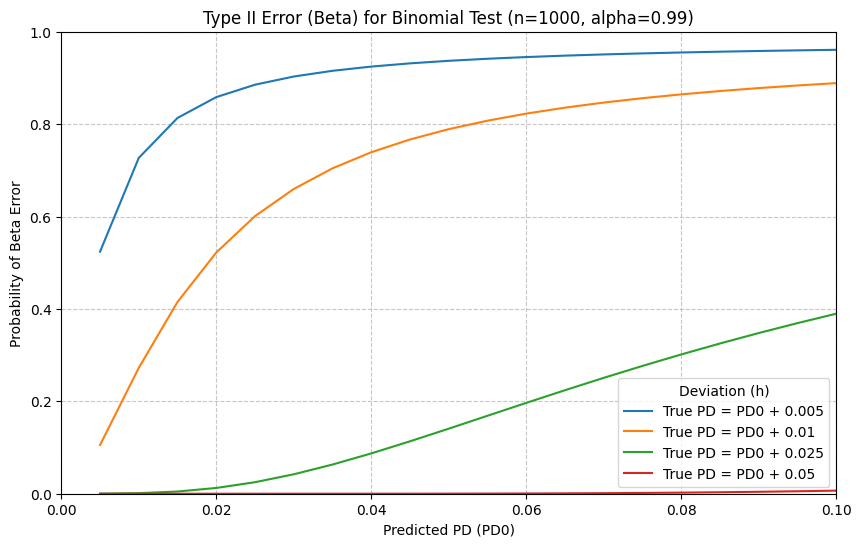

In [65]:
n = 1000
alpha = 0.99
pd0_range = np.arange(0.005, 0.105, 0.005)
h_values = [0.005, 0.01, 0.025, 0.05]

# Inverse Normal CDF (PROBIT)
z_alpha = stats.norm.ppf(alpha)

results = []

for pd0 in pd0_range:
    row = {'PD0': pd0}
    for h in h_values:
        pd_true = pd0 + h
        
        # Normal Approximation Formula for Beta
        numerator = pd0 - pd_true + z_alpha * np.sqrt(pd0 * (1 - pd0) / n)
        denominator = np.sqrt(pd_true * (1 - pd_true) / n)
        
        beta = stats.norm.cdf(numerator / denominator)
        row[f'beta_{h}'] = beta
        
    results.append(row)

df_beta = pd.DataFrame(results)

# 3. Plotting (Equivalent to PROC GPLOT)
plt.figure(figsize=(10, 6))

for h in h_values:
    plt.plot(df_beta['PD0'], df_beta[f'beta_{h}'], label=f'True PD = PD0 + {h}')

plt.xticks(np.arange(0, 0.12, 0.02))
plt.yticks(np.arange(0, 1.2, 0.2))
plt.xlim(0, 0.1)
plt.ylim(0, 1.0)

plt.title(f'Type II Error (Beta) for Binomial Test (n={n}, alpha={alpha})')
plt.xlabel('Predicted PD (PD0)')
plt.ylabel('Probability of Beta Error')
plt.legend(title='Deviation (h)', loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Now let's calculate the Type II Error ($\beta$) for the correlated Binomial test (ASRF model). Unlike the previous exercise, this one accounts for the fact that defaults are linked by a systematic factor (the economy).

By increasing the asset correlation ($\rho$), we see how much harder it becomes to "catch" a poorly calibrated model when the economy is volatile.

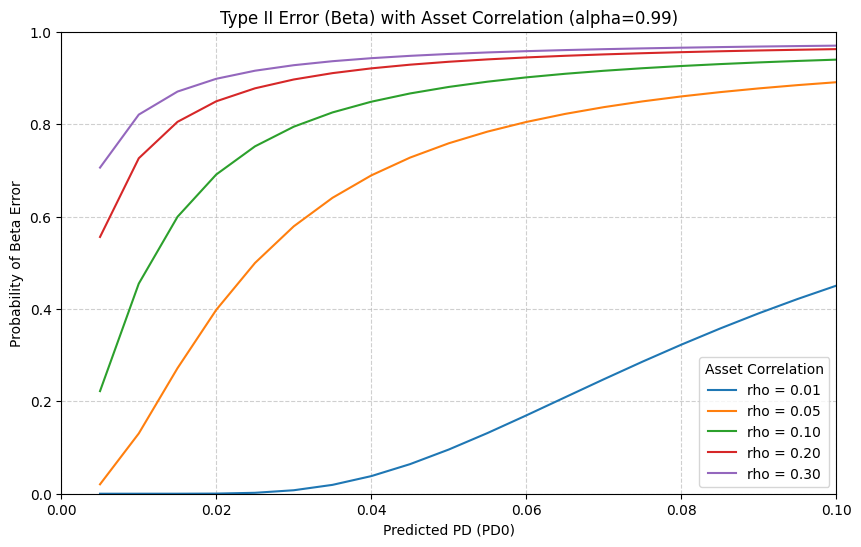

In [64]:
alpha = 0.99
pd0_range = np.arange(0.005, 0.105, 0.005)
rhos = [0.01, 0.05, 0.1, 0.2, 0.3]
z_alpha = stats.norm.ppf(alpha)

results = []

for rho in rhos:
    for pd0 in pd0_range:
        # True PD is 5% higher than predicted PD
        pd1 = pd0 + 0.05
        
        z_pd0 = stats.norm.ppf(pd0)
        z_pd1 = stats.norm.ppf(pd1)
        
        # Step A: Calculate p_crit (The critical threshold in ASRF)
        # Formula: Phi( (Phi^-1(PD0) + sqrt(rho)*Phi^-1(alpha)) / sqrt(1-rho) )
        p_crit = stats.norm.cdf((z_pd0 + np.sqrt(rho) * z_alpha) / np.sqrt(1 - rho))
        z_pcrit = stats.norm.ppf(p_crit)
        
        # Step B: Calculate p_beta (The probability of MISSING the error)
        # Formula: Phi( (sqrt(1-rho)*Phi^-1(p_crit) - Phi^-1(PD1)) / sqrt(rho) )
        numerator = np.sqrt(1 - rho) * z_pcrit - z_pd1
        p_beta = stats.norm.cdf(numerator / np.sqrt(rho))
        
        results.append({'PD0': pd0, 'rho': rho, 'beta': p_beta})

df_corr_beta = pd.DataFrame(results)

plt.figure(figsize=(10, 6))

for rho in rhos:
    subset = df_corr_beta[df_corr_beta['rho'] == rho]
    plt.plot(subset['PD0'], subset['beta'], label=f'rho = {rho:.2f}')

plt.xticks(np.arange(0, 0.12, 0.02))
plt.yticks(np.arange(0, 1.2, 0.2))
plt.xlim(0, 0.1)
plt.ylim(0, 1.0)

plt.title(f'Type II Error (Beta) with Asset Correlation (alpha={alpha})')
plt.xlabel('Predicted PD (PD0)')
plt.ylabel('Probability of Beta Error')
plt.legend(title='Asset Correlation', loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Data Aggregation
To achieve statistical significance, backtesting requires a sufficient number of observations per rating.
* **Granularity vs. Power:** Having too many rating grades ($G$) reduces the observations per grade ($n/G$), which increases standard errors.
* **The Strategy:** Aggregate data by merging similar rating buckets (e.g., AA+, AA, and AA- into one "AA" grade) or segmenting at the portfolio level to increase the robustness of the test results.

### Risk Philosophy
The "Risk Philosophy" determines what a "pass" looks like during validation:

#### **Point-in-Time (PIT)**
* **Nature:** Reactive to economic cycles.
* **Validation:** Expected to match realized 12-month default rates closely.

#### **Through-the-Cycle (TTC)**
* **Nature:** Stable; ignores temporary economic swings.
* **Validation:** Realized default rates are expected to rise above the $PD$ in downturns and fall below it in upturns. Validation should be performed against the **average default rate over a full economic cycle**.

### The Traffic Light Dashboard
To facilitate oversight, all backtesting results are synthesized into a "Traffic Light" system across the three architectural levels:

| Level | Component | Green (🟢) | Yellow (🟡) | Red (🔴) |
| :--- | :--- | :--- | :--- | :--- |
| **Level 2** | **Calibration** | Not significant at 95% | Significant (95% - 99%) | Significant (> 99%) |
| **Level 1** | **Discrimination** | AUC Diff < 2.5% | AUC Diff 2.5% - 5% | AUC Diff > 5% |
| **Level 0** | **Data Stability** | SSI < 0.10 | SSI 0.10 - 0.25 | SSI > 0.25 |

> **Note:** Qualitative tests (like documentation quality or expert overrides) are equally important and are color-coded based on the severity of issues found.

---

### Hierarchical Action Plan
When a model triggers a **Red** or **Yellow** light, the following diagnostic path is followed:

1. **Is Calibration the only issue?**  If Level 1 (Discrimination) is still strong, apply a **Scaling Factor** to recalibrate the PDs.
2. **Is Discrimination failing?**  Check Level 0 (Data Stability). If the population is stable but the model isn't ranking risk, the model logic is likely outdated.
3. **Is the Data unstable?**  If Level 0 shows major shifts (SSI > 0.25), a full **Model Re-estimation** is required.

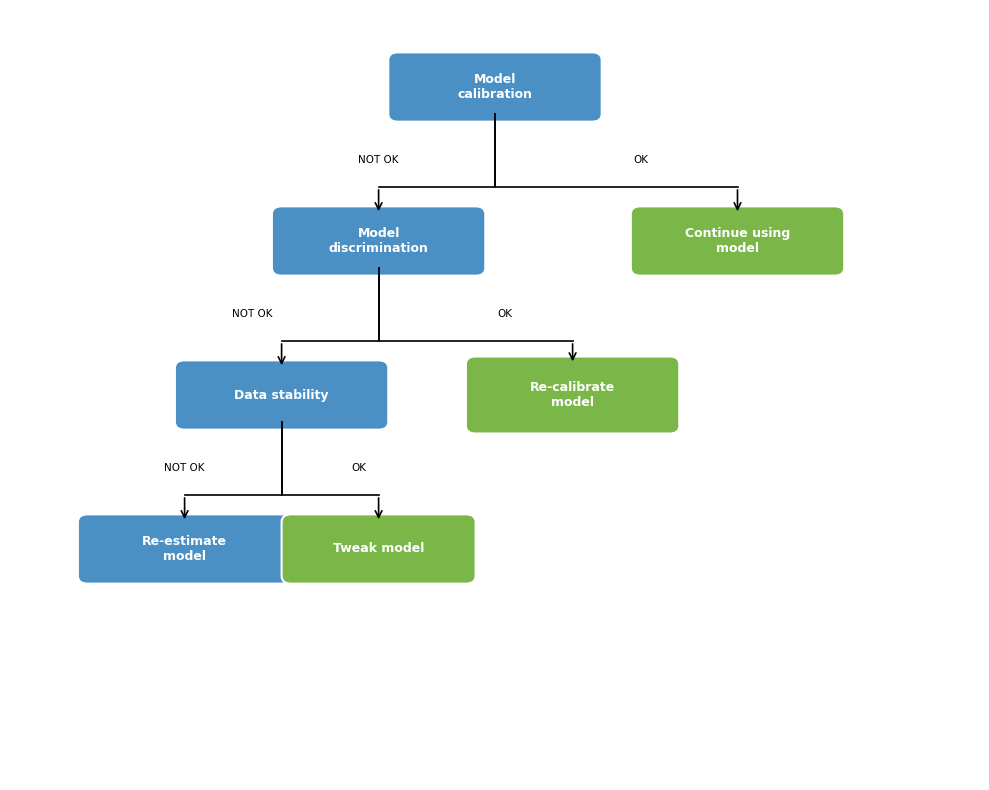

In [66]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

BLUE  = '#4A90C4'
GREEN = '#7AB648'
WHITE = 'white'

def draw_box(ax, cx, cy, w, h, text, color, fontsize=9):
    x, y = cx - w/2, cy - h/2
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle="round,pad=0.1",
                         facecolor=color,
                         edgecolor=WHITE,
                         linewidth=1.5)
    ax.add_patch(box)
    ax.text(cx, cy, text, ha='center', va='center',
            color=WHITE, fontsize=fontsize,
            fontweight='bold', multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='black',
                                lw=1.2, mutation_scale=12))

def label(ax, x, y, text, fontsize=8):
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, color='black')

# ── Node positions ────────────────────────────────────────────────
# Row 1: Model calibration (top center)
draw_box(ax, 5.0, 9.0, 2.0, 0.7, 'Model\ncalibration',   BLUE,  9)

# Row 2: Model discrimination (left) | Continue using model (right)
draw_box(ax, 3.8, 7.0, 2.0, 0.7, 'Model\ndiscrimination', BLUE,  9)
draw_box(ax, 7.5, 7.0, 2.0, 0.7, 'Continue using\nmodel',  GREEN, 9)

# Row 3: Data stability (left) | Re-calibrate model (right)
draw_box(ax, 2.8, 5.0, 2.0, 0.7, 'Data stability',        BLUE,  9)
draw_box(ax, 5.8, 5.0, 2.0, 0.8, 'Re-calibrate\nmodel',   GREEN, 9)

# Row 4: Re-estimate model (left) | Tweak model (right)
draw_box(ax, 1.8, 3.0, 2.0, 0.7, 'Re-estimate\nmodel',    BLUE,  9)
draw_box(ax, 3.8, 3.0, 1.8, 0.7, 'Tweak model',           GREEN, 9)

# ── Arrows ────────────────────────────────────────────────────────
# Calibration -> Discrimination (NOT OK, goes left-down)
ax.plot([5.0, 5.0, 3.8], [8.65, 7.7, 7.7], color='black', lw=1.2)
draw_arrow(ax, 3.8, 7.7, 3.8, 7.35)

# Calibration -> Continue using model (OK, goes right-down)
ax.plot([5.0, 5.0, 7.5], [8.65, 7.7, 7.7], color='black', lw=1.2)
draw_arrow(ax, 7.5, 7.7, 7.5, 7.35)

# Discrimination -> Data stability (NOT OK)
ax.plot([3.8, 3.8, 2.8], [6.65, 5.7, 5.7], color='black', lw=1.2)
draw_arrow(ax, 2.8, 5.7, 2.8, 5.35)

# Discrimination -> Re-calibrate model (OK)
ax.plot([3.8, 3.8, 5.8], [6.65, 5.7, 5.7], color='black', lw=1.2)
draw_arrow(ax, 5.8, 5.7, 5.8, 5.40)

# Data stability -> Re-estimate model (NOT OK)
ax.plot([2.8, 2.8, 1.8], [4.65, 3.7, 3.7], color='black', lw=1.2)
draw_arrow(ax, 1.8, 3.7, 1.8, 3.35)

# Data stability -> Tweak model (OK)
ax.plot([2.8, 2.8, 3.8], [4.65, 3.7, 3.7], color='black', lw=1.2)
draw_arrow(ax, 3.8, 3.7, 3.8, 3.35)

# ── Branch labels ─────────────────────────────────────────────────
label(ax, 3.8, 8.05, 'NOT OK', 7.5)
label(ax, 6.5, 8.05, 'OK',     7.5)

label(ax, 2.5, 6.05, 'NOT OK', 7.5)
label(ax, 5.1, 6.05, 'OK',     7.5)

label(ax, 1.8, 4.05, 'NOT OK', 7.5)
label(ax, 3.6, 4.05, 'OK',     7.5)

plt.tight_layout()
plt.savefig('model_validation_tree.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

## Backtesting LGD and EAD

Remember that both models are typically developed using similar methodologies. Hence, the backtesting procedures will also be similar. As in the book, the techniques will be illustrate using LGDs only, but application to EADs is straigthforward using the same codes. The levels will be the same as PDs.

As with level 0 we have the same tests as for the PD, this one will be skiped.

### Backtesting at Level 1

At level 1, discrimination can be verified using ROC plots and corresponding AUROCs and ARs. However, defaults are binary variables whereas LGDs and EADs are metric variables. Therefore, some adjustments have to be made.

In [68]:
from sklearn.model_selection import train_test_split

# random_state ensures you get the same split every time you run the code
lgd_is, lgd_os = train_test_split(lgd, test_size=0.20, random_state=42)

print(f"Total Observations: {len(lgd)}")
print(f"In-Sample (Training) size: {len(lgd_is)}")
print(f"Out-of-Sample (Validation) size: {len(lgd_os)}")
print("\nIn-Sample Event Rate:")
print(lgd_is['event'].mean())
print("\nOut-of-Sample Event Rate:")
print(lgd_os['event'].mean())

Total Observations: 2545
In-Sample (Training) size: 2036
Out-of-Sample (Validation) size: 509

In-Sample Event Rate:
0.7170923379174853

Out-of-Sample Event Rate:
0.7013752455795678


                            OLS Regression Results                            
Dep. Variable:               lgd_time   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                     225.6
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           3.37e-89
Time:                        10:37:19   Log-Likelihood:                -423.34
No. Observations:                2036   AIC:                             852.7
Df Residuals:                    2033   BIC:                             869.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0270      0.014     -1.939      0.0

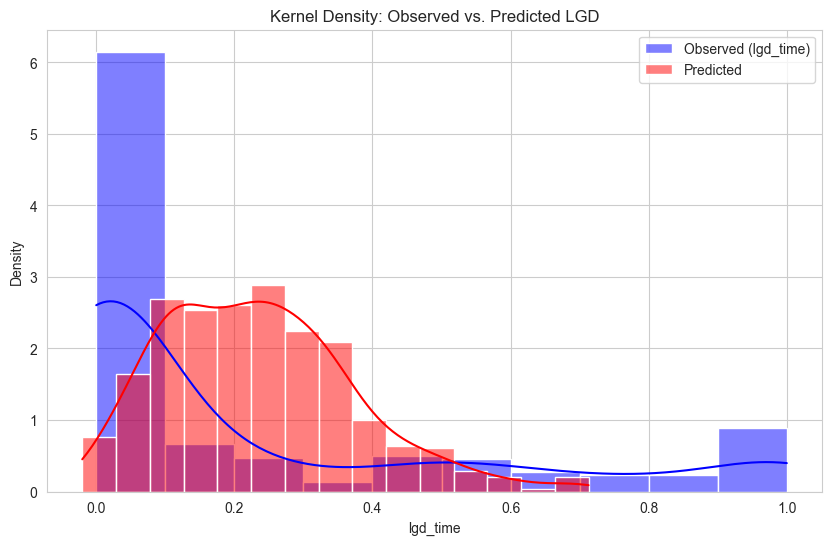

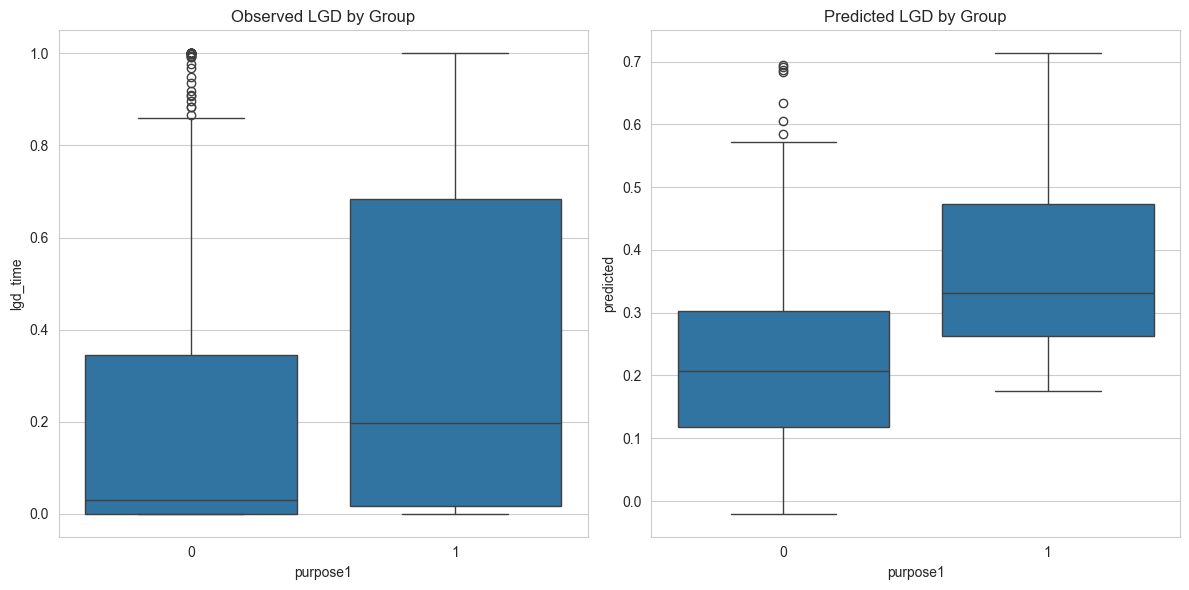

In [90]:
formula = "lgd_time ~ LTV + purpose1"
model1 = smf.ols(formula, data=lgd_is).fit()

# View regression details (Equivalent to DETAILS=ALL)
print(model1.summary())

# Generate predictions for the Out-of-Sample dataset
lgd_os['predicted'] = model1.predict(lgd_os)

# 3. Distribution Comparison (Equivalent to PROC UNIVARIATE / HISTOGRAM)
plt.figure(figsize=(10, 6))
sns.histplot(lgd_os['lgd_time'], color="blue", label="Observed (lgd_time)", kde=True, stat="density", alpha=0.5)
sns.histplot(lgd_os['predicted'], color="red", label="Predicted", kde=True, stat="density", alpha=0.5)

plt.title("Kernel Density: Observed vs. Predicted LGD")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
# Plot Observed
plt.subplot(1, 2, 1)
sns.boxplot(x='purpose1', y='lgd_time', data=lgd_os)
plt.title("Observed LGD by Group")

# Plot Predicted
plt.subplot(1, 2, 2)
sns.boxplot(x='purpose1', y='predicted', data=lgd_os)
plt.title("Predicted LGD by Group")

plt.tight_layout()
plt.show()

The histograms show serious deviation between actual and predicted values, which is particularly attributable to the nonnormal shape of the LGD distribution, which cannot be properly fitted by the OLS regression model with only two variables. The model suffers from a classic "Regression to the Mean" effect:

* **Distribution Mismatch:** The observed LGD is **bimodal/zero-inflated** (clustering at 0% and 100% loss). The OLS model generates a **normal distribution**, failing to capture the extremes.
* **Median Bias:** The boxplots show that while the mean might be preserved ($\approx 0.2311$), the medians and quartiles are significantly shifted. The model over-predicts loss for low-risk groups and under-predicts for high-risk groups.
* **Non-Normality:** As stated, LGD is bounded between $[0, 1]$ and highly non-normal. OLS is mathematically incapable of fitting this "U-shape" without significant transformation.

The following points should also be noted:

* **Tail Risk Blindness:** The predicted distribution (red) fails to reach $1.0$. From a capital adequacy perspective, the model is **dangerous** because it ignores the possibility of total loss on a facility.
* **The Binary Threshold ($d(LGD_i)$):** Converting LGD into a binary variable based on the mean observed LGD ($\overline{LGD} = 0.2311$) is an essential step. It allows the use of **ROC/AUC analysis** to determine if the model has any "ranking power" (Level 1 Discrimination), even if its absolute "calibration" (Level 2) is poor.
* **Suggested Remediation:** Given the "NOT OK" status of this calibration, the next step in the action plan should be to explore non-linear models such as **Beta Regression**, **Tobit models**, or **Fractional Response Regressions**, which are designed for $[0, 1]$ bounded data.

$$d(LGD_i) = \begin{cases} 1 & LGD_i \geq \overline{LGD} \\ 0 & LGD_i < \overline{LGD} \end{cases}$$

In [71]:
lgd_os['D_LGD'] = np.where(lgd_os['lgd_time'] > 0.2312, 1, 0)
print("Binary LGD Flag Counts:")
print(lgd_os['D_LGD'].value_counts())

Binary LGD Flag Counts:
D_LGD
0    359
1    150
Name: count, dtype: int64


LGD Model AUC Score: 0.7958


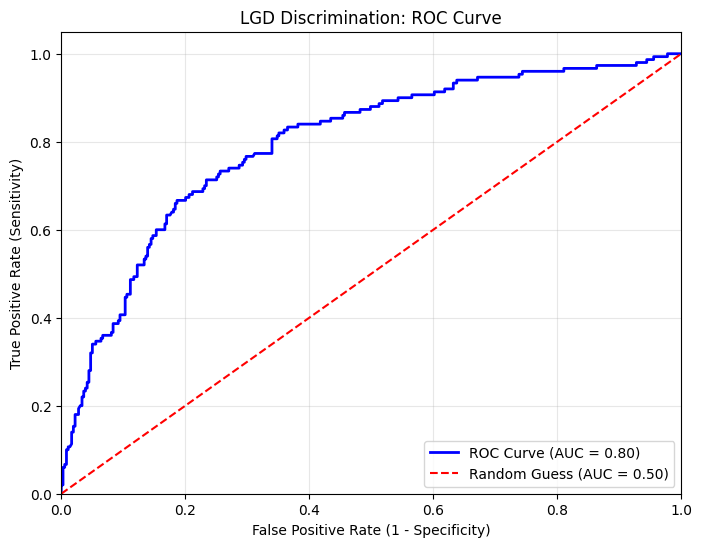

In [ ]:
auc_score = roc_auc_score(lgd_os['D_LGD'], lgd_os['predicted'])
print(f"LGD Model AUC Score: {auc_score:.4f}")
fpr, tpr, thresholds = roc_curve(lgd_os['D_LGD'], lgd_os['predicted'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('LGD Discrimination: ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


The validation results reveal a model that is a **strong ranker** but a **weak predictor**. While the model demonstrates high discrimination power, it fails to accurately predict the absolute percentage of loss (calibration), primarily due to the non-normal, bimodal nature of the LGD data.

| Validation Level | Metric | Result | Status |
| :--- | :--- | :--- | :--- |
| **Level 1: Discrimination** | **AUC Score** | **0.80** | 🟢 **PASS** |
| **Level 2: Calibration** | **Histogram/KDE** | **Significant Deviation** | 🔴 **FAIL** |

The high AUC indicates that the model is effectively distinguishing between "High Loss" and "Low Loss" accounts. Even though the OLS regression isn't hitting the exact values, the underlying variables ($LTV$, $purpose1$) are successfully ranking the risk.

The model suffers from **"Regression to the Mean."** * **The Reality:** LGD is bimodal (clustering at $0$ and $1$).
* **The Model:** Predicts a normal distribution around the average ($\approx 0.23$).
* **The Risk:** This creates a dangerous blindness to "Tail Risk," where the model under-estimates the likelihood of a $100\%$ loss event.

Following the standard model validation flowchart, the model requires immediate remedial action focused on **re-calibration** rather than a full rebuild.

* **Decision:** **RE-CALIBRATE MODEL**
* **Rationale:** Since the discrimination is strong (Level 1 is OK), the "logic" of the model is sound. We only need to fix the "link" between the linear predictor and the final output to better fit the bimodal distribution.
* **Proposed Solution:** Implement a **Two-Stage Model** (e.g., Tobit) or a **Fractional Response Regression** (Logit/Probit link) to better handle the $[0, 1]$ bounds and zero-inflation.


As established, standard linear correlation is ill-suited for LGD validation due to the highly non-normal, typically bimodal distribution of LGD data. Parametric measures implicitly assume normality and a linear relationship between variables — assumptions that LGD empirically violates, rendering metrics such as Pearson's rr
r misleading in this context.

Non-parametric rank-based measures offer a more robust alternative, as they depend only on the relative ordering of observations rather than their absolute values, making them distribution-free by construction. While the ROC curve provides an intuitive visual assessment of the model's discriminatory power, rank correlation coefficients — specifically Spearman's $\rho$ and Kendall's $\tau$ — provide the formal statistical quantification of the monotonic association between observed ($LGD^{obs}$) and predicted ($LGD^{pred}$) losses. Together, these tools form a complementary validation framework: one diagnostic, one inferential.

* **Pearson (Bravais-Pearson):** Measures linear association. It is often misleading in LGD validation due to the bimodal nature of the data.
* **Spearman ($\theta$):** Assesses monotonic relationships by correlating the **ranks** of the observations.
* **Kendall ($\tau$-b):** Evaluates the **concordance** of pairs, making it highly robust against non-normal distributions and outliers.


##### Spearman Rank Correlation Formula
$$\theta = \frac{\sum_i (R_i - \overline{R})(S_i - \overline{S})}{\sqrt{\sum_i (R_i - \overline{R})^2 \sum_i (S_i - \overline{S})^2}}$$

* $R_i, S_i$: Ranks of observed and predicted values.
* $\overline{R}, \overline{S}$: Average ranks.

##### Kendall’s $\tau$-b Formula
$$\tau = \frac{\sum_{i<j} (\text{sgn}(LGD_i^{obs} - LGD_j^{obs})\text{sgn}(LGD_i^{pred} - LGD_j^{pred}))}{\sqrt{(T_0 - T_1)(T_0 - T_2)}}$$

* **Concordance Logic:** If $\text{sgn}(LGD_i^{obs} - LGD_j^{obs}) = \text{sgn}(LGD_i^{pred} - LGD_j^{pred})$, the model correctly ordered the risk of the two loans.
* **Tie Handling:** $T_1$ and $T_2$ adjust the denominator to account for identical values in the dataset.


In [73]:
correlations = {
    "Pearson":  lgd_os['lgd_time'].corr(lgd_os['predicted'], method='pearson'),
    "Spearman": lgd_os['lgd_time'].corr(lgd_os['predicted'], method='spearman'),
    "Kendall":  lgd_os['lgd_time'].corr(lgd_os['predicted'], method='kendall')
}

print("--- LGD Model Association Metrics ---")
for method, value in correlations.items():
    print(f"{method:8}: {value:.4f}")

--- LGD Model Association Metrics ---
Pearson : 0.4940
Spearman: 0.5000
Kendall : 0.3539


Now let's try and recalibrate our model. The original OLS model `lgd_time ~ LTV + purpose1` has two fundamental flaws for LGD data:

- **OLS assumes a normal distribution** — but our LGD is heavily skewed with 55% of values below 0.05 and a long tail. OLS treats all observations equally, so it gets pulled toward the middle and predicts everything around 0.22 regardless of the true value.

- **OLS is unbounded** — it produced negative predictions (min = −0.026), which are economically meaningless for a loss rate.

The result: predicted mean ≈ observed mean (0.233 vs 0.224) but the *distribution* is completely wrong — no spike at the low end, no high tail.

So how to fix it? The core idea is **divide the data into three structurally different groups and model each separately**, then recombine.

First we segment the data by the LGD value on the In-Sample data (IS)
```
LGD ≤ 0.05  →  "low"    segment  (55% of IS)
LGD ≥ 0.90  →  "high"   segment  (9%  of IS)
otherwise   →  "middle" segment  (36% of IS)
```
These thresholds reflect real economic behaviour — low LGD accounts recovered nearly everything, high LGD accounts lost nearly everything, and middle accounts had partial losses. A logistic regression trained **on IS only** using `LTV`, `Recovery_rate`, `purpose1` learns to predict, for any new OS account:
```
P(this account belongs to low segment)
P(this account belongs to middle segment)  
P(this account belongs to high segment)
```
These three probabilities always sum to 1.

Instead of one model for everything, we fit **separate GLM Binomial models** for the middle and high segments:

- **Middle severity**: GLM trained only on IS accounts where `0.05 < LGD < 0.90` — learns what drives partial losses
- **High severity**: GLM trained only on IS accounts where `LGD ≥ 0.90` — learns what drives near-total losses
- **Low severity**: No model needed — just use the IS mean of the low group (≈ 0.02), since these accounts all behaved similarly

We use GLM Binomial (not OLS) because it respects the [0,1] bounds by construction.

For each OS account, the final prediction is a **probability-weighted average**:

$$\hat{LGD} = P(\text{low}) \times \mu_{\text{low}} + P(\text{mid}) \times \mu_{\text{mid}} + P(\text{high}) \times \mu_{\text{high}}$$

Concretely for an account the classifier thinks is likely low-LGD:
- `P(low) = 0.87, P(mid) = 0.12, P(high) = 0.01`
- `pred_v2 = 0.87 × 0.02 + 0.12 × 0.35 + 0.01 × 0.95 ≈ 0.07`

For an account likely to be high-LGD:
- `P(low) = 0.05, P(mid) = 0.20, P(high) = 0.75`
- `pred_v2 = 0.05 × 0.02 + 0.20 × 0.35 + 0.75 × 0.95 ≈ 0.78`

This is what allows the model to **span the full [0,1] range** rather than compressing everything around the mean.

IS segment counts:
segment_v2
low       1121
middle     727
high       188
Name: count, dtype: int64
  low  mean: 0.0086
  mid  mean: 0.3736
  high mean: 0.9847

OS segment predictions:
low       324
middle    135
high       50
Name: count, dtype: int64
Mean P(low)=0.558, P(mid)=0.351, P(high)=0.091

Middle IS: n=727, LGD range=[0.050, 0.899]
High   IS: n=188, LGD range=[0.900, 1.000]

Middle GLM converged: True
High   GLM converged: True

Severity checks:
  severity_mid  — min=0.0731, mean=0.2566, max=0.9249
  severity_high — min=0.0000, mean=0.1006, max=0.9968
  LGD_LOW_MEAN  = 0.0086

Metric                      Model1 (OLS) Model2 (3-part)
-------------------------------------------------------
Observed Mean                     0.2243         0.2243
Predicted Mean                    0.2339         0.2078
|Difference|                      0.0097         0.0165
Spearman rho                      0.5000         0.9473
RMSE                              0.2863         0.0443

Weighted co

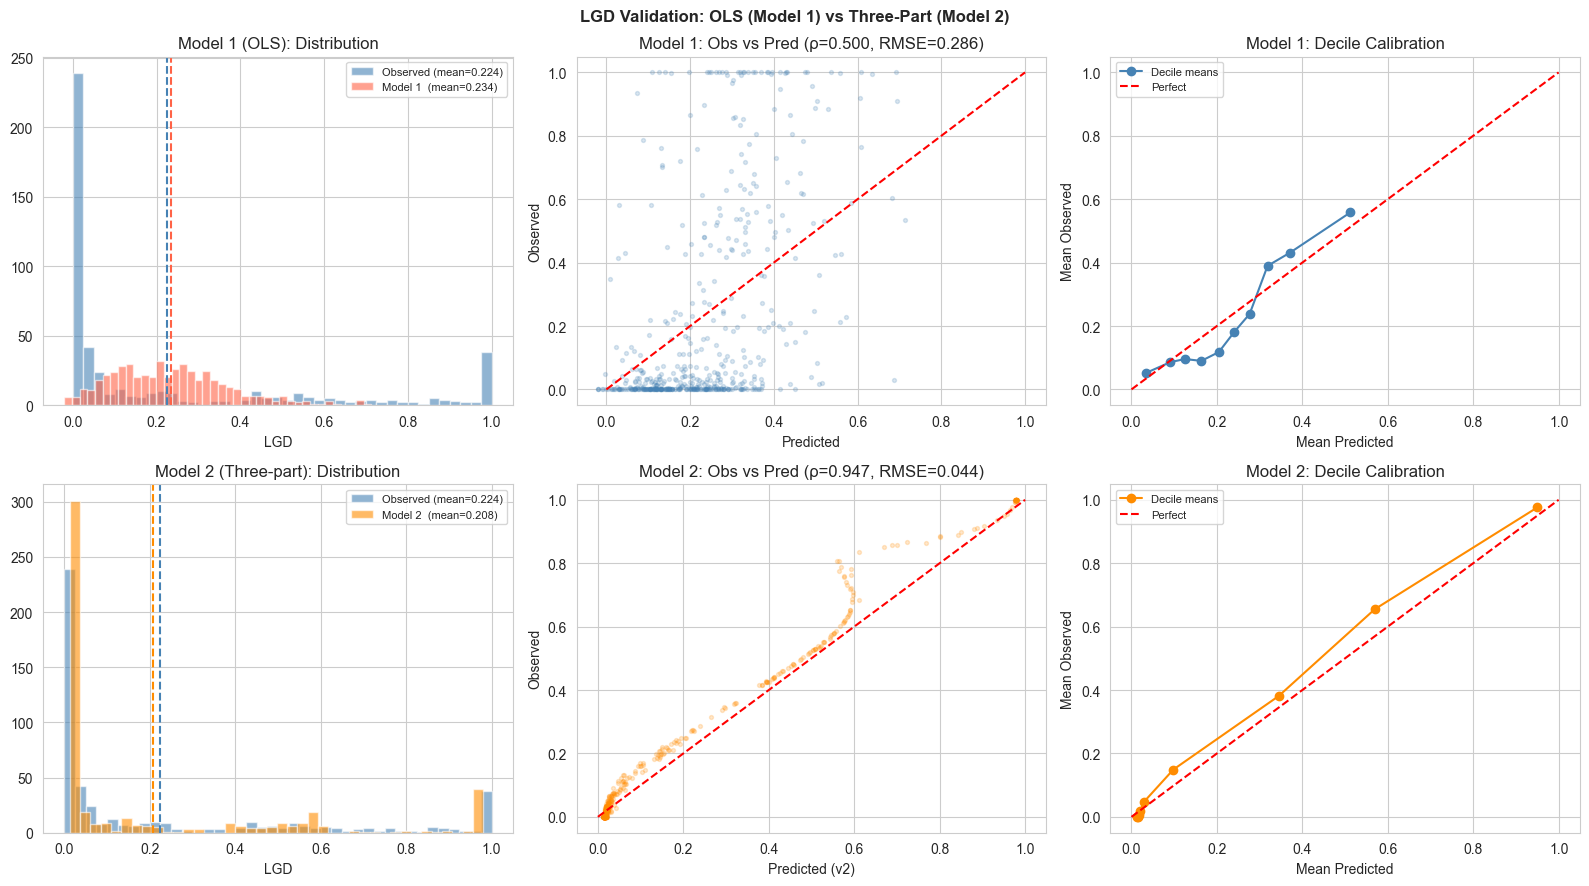

In [ ]:
FEATURES   = ['LTV', 'Recovery_rate', 'purpose1']
SPLIT_LOW  = 0.05
SPLIT_HIGH = 0.90

# ── Step 1: Segments ──────────────────────────────────────────────
def assign_segment(df, split_low, split_high):
    seg = pd.Series('middle', index=df.index)
    seg[df['lgd_time'] <= split_low]  = 'low'
    seg[df['lgd_time'] >= split_high] = 'high'
    return seg

lgd_is['segment_v2'] = assign_segment(lgd_is, SPLIT_LOW, SPLIT_HIGH)

print("IS segment counts:")
print(lgd_is['segment_v2'].value_counts())
print(f"  low  mean: {lgd_is[lgd_is['segment_v2']=='low']['lgd_time'].mean():.4f}")
print(f"  mid  mean: {lgd_is[lgd_is['segment_v2']=='middle']['lgd_time'].mean():.4f}")
print(f"  high mean: {lgd_is[lgd_is['segment_v2']=='high']['lgd_time'].mean():.4f}")

# ── Step 2: Segment classifier ────────────────────────────────────
seg_clf = LogisticRegression(solver='lbfgs', max_iter=2000)
seg_clf.fit(lgd_is[FEATURES], lgd_is['segment_v2'])

seg_classes     = list(seg_clf.classes_)
seg_probs_os    = seg_clf.predict_proba(lgd_os[FEATURES])
p_low_os        = seg_probs_os[:, seg_classes.index('low')]
p_middle_os     = seg_probs_os[:, seg_classes.index('middle')]
p_high_os       = seg_probs_os[:, seg_classes.index('high')]

print(f"\nOS segment predictions:")
print(pd.Series(seg_clf.predict(lgd_os[FEATURES])).value_counts())
print(f"Mean P(low)={p_low_os.mean():.3f}, P(mid)={p_middle_os.mean():.3f}, P(high)={p_high_os.mean():.3f}")

# ── Step 3: Severity models using FEATURES directly (not predicted)─
# Problem: predicted_is has negative values → logit breaks
# Solution: use GLM with actual features as regressors

mid_is  = lgd_is[lgd_is['segment_v2'] == 'middle'].copy()
high_is = lgd_is[lgd_is['segment_v2'] == 'high'].copy()

print(f"\nMiddle IS: n={len(mid_is)}, LGD range=[{mid_is['lgd_time'].min():.3f}, {mid_is['lgd_time'].max():.3f}]")
print(f"High   IS: n={len(high_is)}, LGD range=[{high_is['lgd_time'].min():.3f}, {high_is['lgd_time'].max():.3f}]")

# Middle severity: GLM Binomial on features
X_mid_is = sm.add_constant(mid_is[FEATURES])
glm_mid  = sm.GLM(
    np.clip(mid_is['lgd_time'], 0.001, 0.999),
    X_mid_is,
    family=sm.families.Binomial()
).fit()
print(f"\nMiddle GLM converged: {glm_mid.converged}")

# High severity: GLM Binomial on features
X_high_is = sm.add_constant(high_is[FEATURES])
glm_high  = sm.GLM(
    np.clip(high_is['lgd_time'], 0.001, 0.999),
    X_high_is,
    family=sm.families.Binomial()
).fit()
print(f"High   GLM converged: {glm_high.converged}")

# ── Step 4: Score OS ──────────────────────────────────────────────
X_os = sm.add_constant(lgd_os[FEATURES])

# Align columns in case add_constant behaves differently
X_os = X_os.reindex(columns=X_mid_is.columns, fill_value=0)

severity_mid_os  = glm_mid.predict(X_os)
severity_high_os = glm_high.predict(X_os)

LGD_LOW_MEAN = lgd_is[lgd_is['segment_v2'] == 'low']['lgd_time'].mean()

print(f"\nSeverity checks:")
print(f"  severity_mid  — min={severity_mid_os.min():.4f}, mean={severity_mid_os.mean():.4f}, max={severity_mid_os.max():.4f}")
print(f"  severity_high — min={severity_high_os.min():.4f}, mean={severity_high_os.mean():.4f}, max={severity_high_os.max():.4f}")
print(f"  LGD_LOW_MEAN  = {LGD_LOW_MEAN:.4f}")

# ── Step 5: Combine ───────────────────────────────────────────────
lgd_os['pred_v2'] = (p_low_os    * LGD_LOW_MEAN     +
                     p_middle_os * severity_mid_os   +
                     p_high_os   * severity_high_os)

# ── Step 6: Evaluation ────────────────────────────────────────────
obs_mean   = lgd_os['lgd_time'].mean()
pred1_mean = lgd_os['predicted'].mean()
pred2_mean = lgd_os['pred_v2'].mean()

spear1, _ = spearmanr(lgd_os['lgd_time'], lgd_os['predicted'])
spear2, _ = spearmanr(lgd_os['lgd_time'], lgd_os['pred_v2'])
rmse1     = np.sqrt(((lgd_os['lgd_time'] - lgd_os['predicted'])**2).mean())
rmse2     = np.sqrt(((lgd_os['lgd_time'] - lgd_os['pred_v2'])**2).mean())

print(f"\n{'='*55}")
print(f"{'Metric':<25} {'Model1 (OLS)':>14} {'Model2 (3-part)':>14}")
print(f"{'-'*55}")
print(f"{'Observed Mean':<25} {obs_mean:>14.4f} {obs_mean:>14.4f}")
print(f"{'Predicted Mean':<25} {pred1_mean:>14.4f} {pred2_mean:>14.4f}")
print(f"{'|Difference|':<25} {abs(obs_mean-pred1_mean):>14.4f} {abs(obs_mean-pred2_mean):>14.4f}")
print(f"{'Spearman rho':<25} {spear1:>14.4f} {spear2:>14.4f}")
print(f"{'RMSE':<25} {rmse1:>14.4f} {rmse2:>14.4f}")
print(f"{'='*55}")

print(f"\nWeighted components:")
print(f"  P(low)  ×  {LGD_LOW_MEAN:.4f}        = {(p_low_os * LGD_LOW_MEAN).mean():.4f}")
print(f"  P(mid)  ×  {severity_mid_os.mean():.4f} (sev_mid)  = {(p_middle_os * severity_mid_os).mean():.4f}")
print(f"  P(high) ×  {severity_high_os.mean():.4f} (sev_high) = {(p_high_os * severity_high_os).mean():.4f}")

# ── Step 7: Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1 — Model 1 (OLS baseline)
axes[0, 0].hist(lgd_os['lgd_time'],  bins=40, alpha=0.6,
                color='steelblue', label=f'Observed (mean={obs_mean:.3f})')
axes[0, 0].hist(lgd_os['predicted'], bins=40, alpha=0.6,
                color='tomato',    label=f'Model 1  (mean={pred1_mean:.3f})')
axes[0, 0].axvline(obs_mean,   color='steelblue', linestyle='--', lw=1.5)
axes[0, 0].axvline(pred1_mean, color='tomato',    linestyle='--', lw=1.5)
axes[0, 0].set_title('Model 1 (OLS): Distribution')
axes[0, 0].set_xlabel('LGD')
axes[0, 0].legend(fontsize=8)

axes[0, 1].scatter(lgd_os['predicted'], lgd_os['lgd_time'],
                   alpha=0.2, s=8, color='steelblue')
axes[0, 1].plot([0, 1], [0, 1], 'r--', lw=1.5)
axes[0, 1].set_title(f'Model 1: Obs vs Pred (ρ={spear1:.3f}, RMSE={rmse1:.3f})')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Observed')

lgd_os['_d1'] = pd.qcut(lgd_os['predicted'], q=10, labels=False, duplicates='drop')
d1 = lgd_os.groupby('_d1').agg(obs=('lgd_time','mean'), pred=('predicted','mean')).reset_index()
axes[0, 2].plot(d1['pred'], d1['obs'], 'o-', color='steelblue', label='Decile means')
axes[0, 2].plot([0, 1], [0, 1], 'r--', lw=1.5, label='Perfect')
axes[0, 2].set_title('Model 1: Decile Calibration')
axes[0, 2].set_xlabel('Mean Predicted')
axes[0, 2].set_ylabel('Mean Observed')
axes[0, 2].legend(fontsize=8)

# Row 2 — Model 2 (three-part)
axes[1, 0].hist(lgd_os['lgd_time'], bins=40, alpha=0.6,
                color='steelblue',  label=f'Observed (mean={obs_mean:.3f})')
axes[1, 0].hist(lgd_os['pred_v2'],  bins=40, alpha=0.6,
                color='darkorange', label=f'Model 2  (mean={pred2_mean:.3f})')
axes[1, 0].axvline(obs_mean,   color='steelblue',  linestyle='--', lw=1.5)
axes[1, 0].axvline(pred2_mean, color='darkorange', linestyle='--', lw=1.5)
axes[1, 0].set_title('Model 2 (Three-part): Distribution')
axes[1, 0].set_xlabel('LGD')
axes[1, 0].legend(fontsize=8)

axes[1, 1].scatter(lgd_os['pred_v2'], lgd_os['lgd_time'],
                   alpha=0.2, s=8, color='darkorange')
axes[1, 1].plot([0, 1], [0, 1], 'r--', lw=1.5)
axes[1, 1].set_title(f'Model 2: Obs vs Pred (ρ={spear2:.3f}, RMSE={rmse2:.3f})')
axes[1, 1].set_xlabel('Predicted (v2)')
axes[1, 1].set_ylabel('Observed')

lgd_os['_d2'] = pd.qcut(lgd_os['pred_v2'], q=10, labels=False, duplicates='drop')
d2 = lgd_os.groupby('_d2').agg(obs=('lgd_time','mean'), pred=('pred_v2','mean')).reset_index()
axes[1, 2].plot(d2['pred'], d2['obs'], 'o-', color='darkorange', label='Decile means')
axes[1, 2].plot([0, 1], [0, 1], 'r--', lw=1.5, label='Perfect')
axes[1, 2].set_title('Model 2: Decile Calibration')
axes[1, 2].set_xlabel('Mean Predicted')
axes[1, 2].set_ylabel('Mean Observed')
axes[1, 2].legend(fontsize=8)

plt.suptitle('LGD Validation: OLS (Model 1) vs Three-Part (Model 2)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Cleanup ───────────────────────────────────────────────────────
lgd_os.drop(columns=['_d1', '_d2'], inplace=True)

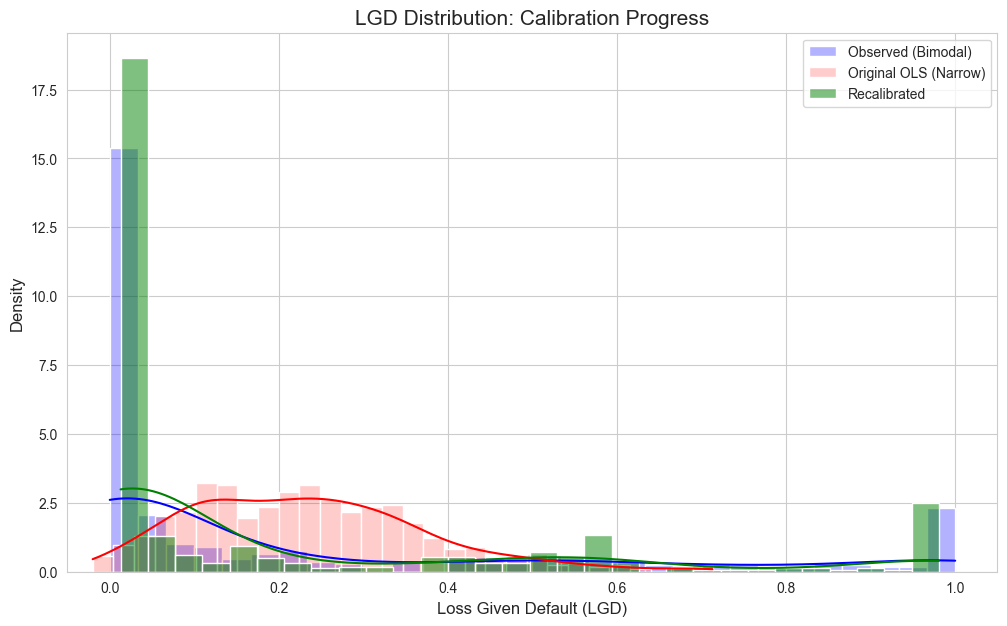

In [98]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 2. Plot Observed LGD (The Ground Truth - Bimodal)
sns.histplot(lgd_os['lgd_time'], color="blue", label="Observed (Bimodal)", 
             kde=True, stat="density", alpha=0.3, bins=30)

# 3. Plot Original OLS (The "Mean Reversion" Error)
sns.histplot(lgd_os['predicted'], color="red", label="Original OLS (Narrow)", 
             kde=True, stat="density", alpha=0.2, bins=30)

# 4. Plot GLM Recalibrated (The "Stretched" Fix)
sns.histplot(lgd_os['pred_v2'], color="green", label="Recalibrated", 
             kde=True, stat="density", alpha=0.5, bins=30)

# 5. Formatting
plt.title("LGD Distribution: Calibration Progress", fontsize=15)
plt.xlabel("Loss Given Default (LGD)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.xlim(-0.05, 1.05) # LGD is bounded [0, 1]

plt.show()

### Backtesting at Level 2.

Now, to check calibration at level 2, we analyze several measures that can be obtained by running a regression on actual versus predicted values.

                            OLS Regression Results                            
Dep. Variable:               lgd_time   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     163.7
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           1.12e-32
Time:                        14:46:04   Log-Likelihood:                -83.655
No. Observations:                 509   AIC:                             171.3
Df Residuals:                     507   BIC:                             179.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0493      0.025     -1.983      0.0

<Figure size 800x600 with 0 Axes>

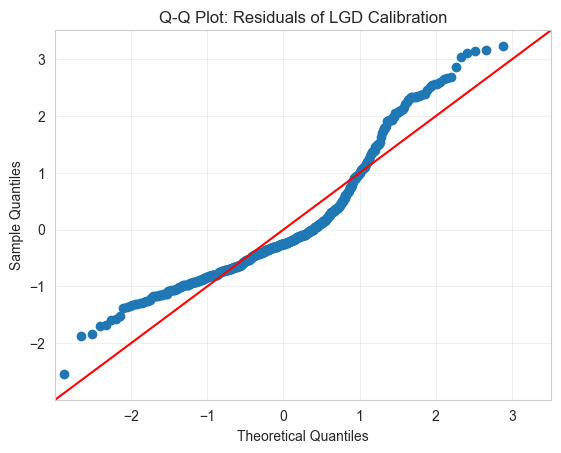

In [100]:
X = sm.add_constant(lgd_os['predicted'])
y = lgd_os['lgd_time']
calibration_reg = sm.OLS(y, X).fit()
print(calibration_reg.summary())
plt.figure(figsize=(8, 6))
sm.qqplot(calibration_reg.resid, line='45', fit=True)
plt.title("Q-Q Plot: Residuals of LGD Calibration")
plt.grid(alpha=0.3)
plt.show()

As we've seen before and can be noticied by low $R^2$, we don't have a good fit.

In [101]:
lgd_os['lgd_time_ranks'] = pd.qcut(lgd_os['lgd_time'], 5, labels=False, duplicates='drop')
means1 = lgd_os.groupby('lgd_time_ranks')[['lgd_time', 'predicted']].mean().reset_index()
print("--- Observed vs. Predicted LGD by Quintile ---")
print(means1)

--- Observed vs. Predicted LGD by Quintile ---
   lgd_time_ranks  lgd_time  predicted
0               0  0.001317   0.166310
1               1  0.036172   0.202227
2               2  0.265294   0.279261
3               3  0.815469   0.355258


We can see that the LGD increases for each group, as it's expected, but still, it's too different from the expected values for the groups far from the mean. Differently from the book, we tried to adjust our fit, let's take a look at how it went.

                            OLS Regression Results                            
Dep. Variable:               lgd_time   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                 3.947e+04
Date:                Sun, 29 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:50:00   Log-Likelihood:                 956.65
No. Observations:                 509   AIC:                            -1909.
Df Residuals:                     507   BIC:                            -1901.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0043      0.002      2.161      0.0

<Figure size 800x600 with 0 Axes>

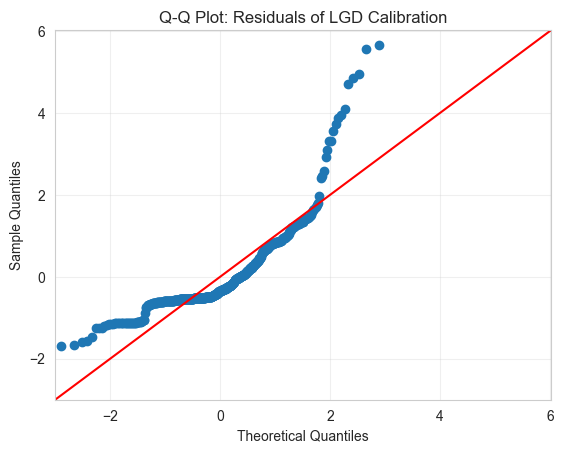

--- Observed vs. Predicted LGD by Quintile ---
   lgd_time_ranks  lgd_time   pred_v2
0               0  0.001317  0.015811
1               1  0.036172  0.024398
2               2  0.265294  0.221208
3               3  0.815469  0.759833


In [102]:
X = sm.add_constant(lgd_os['pred_v2'])
y = lgd_os['lgd_time']
calibration_reg = sm.OLS(y, X).fit()
print(calibration_reg.summary())
plt.figure(figsize=(8, 6))
sm.qqplot(calibration_reg.resid, line='45', fit=True)
plt.title("Q-Q Plot: Residuals of LGD Calibration")
plt.grid(alpha=0.3)
plt.show()

lgd_os['lgd_time_ranks'] = pd.qcut(lgd_os['lgd_time'], 5, labels=False, duplicates='drop')
means1 = lgd_os.groupby('lgd_time_ranks')[['lgd_time', 'pred_v2']].mean().reset_index()
print("--- Observed vs. Predicted LGD by Quintile ---")
print(means1)

As we can see, we are better distributed at the tails, but still, we are punishing a little bit the first group while keeping the other groups a little below the expected value. Still, we have a better fit than before. In any case, I'll keep following the book and go back to the original dataset.

--- Groupwise Descriptive Statistics ---
                lgd_time                               predicted            \
                     min      mean       max       std       min      mean   
lgd_time_ranks                                                               
0               0.000010  0.001317  0.011372  0.002792 -0.020239  0.166310   
1               0.011988  0.036172  0.074144  0.017798 -0.003228  0.202227   
2               0.078895  0.265294  0.519669  0.138692  0.009492  0.279261   
3               0.525486  0.815469  0.999990  0.179511  0.031234  0.355258   

                                    
                     max       std  
lgd_time_ranks                      
0               0.451655  0.097844  
1               0.686016  0.116755  
2               0.572391  0.127804  
3               0.712927  0.143310  


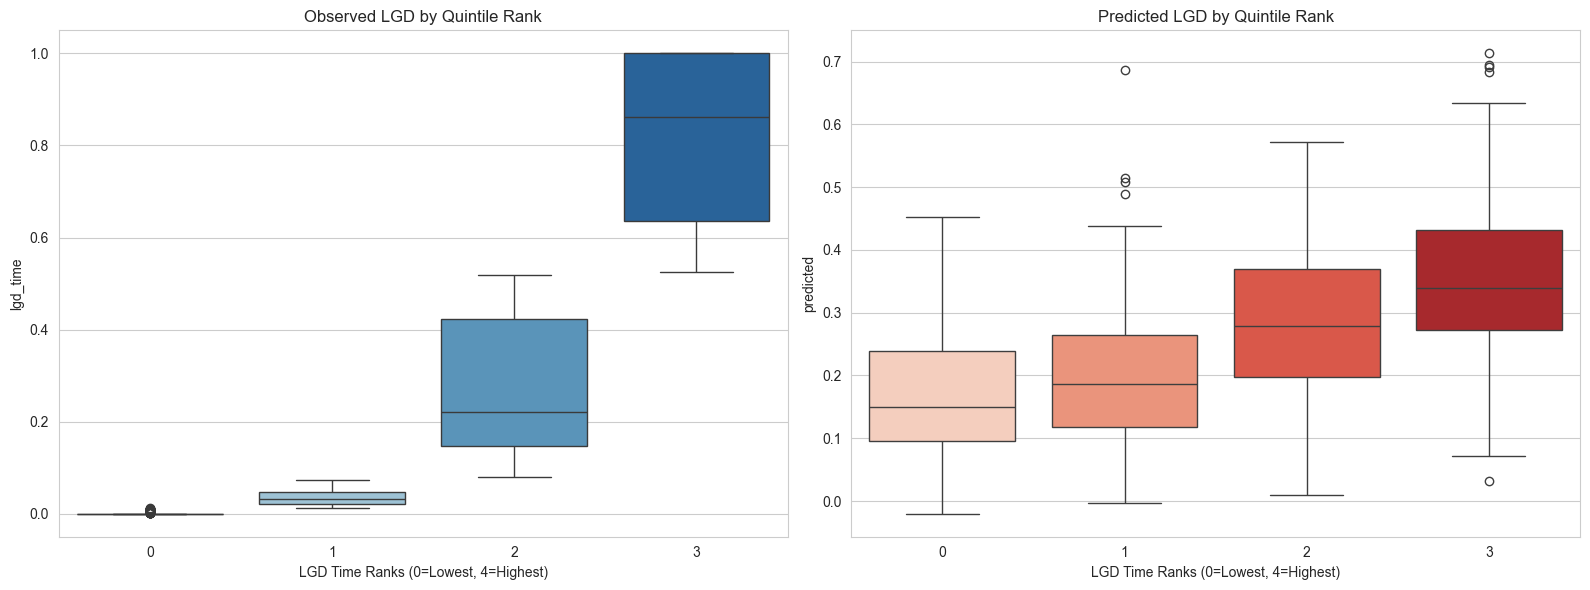

In [103]:
stats_table = lgd_os.groupby('lgd_time_ranks')[['lgd_time', 'predicted']].agg(['min', 'mean', 'max', 'std'])
print("--- Groupwise Descriptive Statistics ---")
print(stats_table)

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='lgd_time_ranks', y='lgd_time', data=lgd_os, palette="Blues")
plt.title("Observed LGD by Quintile Rank")
plt.xlabel("LGD Time Ranks (0=Lowest, 4=Highest)")
plt.subplot(1, 2, 2)
sns.boxplot(x='lgd_time_ranks', y='predicted', data=lgd_os, palette="Reds")
plt.title("Predicted LGD by Quintile Rank")
plt.xlabel("LGD Time Ranks (0=Lowest, 4=Highest)")

plt.tight_layout()
plt.show()

As we can see, the boxplots confirms that while the predicted LGD increases for each bucket, it's still very different from the expected values.

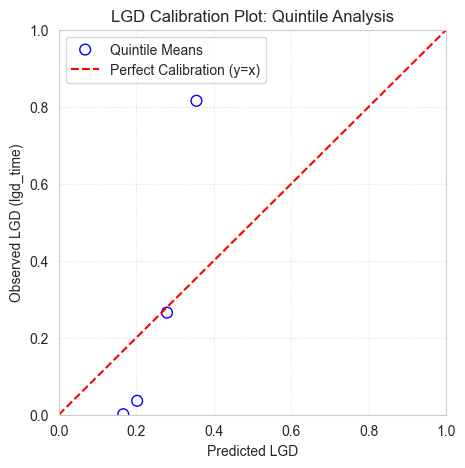

In [106]:

means1 = lgd_os.groupby('lgd_time_ranks')[['lgd_time', 'predicted']].mean().reset_index()
plt.figure(figsize=(5, 5))
plt.scatter(means1['predicted'], means1['lgd_time'], 
            color='blue', marker='o', facecolors='none', s=60, label='Quintile Means')
ticks = np.arange(0, 1.2, 0.2)
plt.xticks(ticks)
plt.yticks(ticks)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect Calibration (y=x)')
plt.xlabel('Predicted LGD')
plt.ylabel('Observed LGD (lgd_time)')
plt.title('LGD Calibration Plot: Quintile Analysis')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

### Benchmarking

Benchmarking is a quantitative validation activity used to ensure a model is optimal by contrasting it with a reference point. Comparing internal outputs to external agencies (e.g., FICO or Moody’s) provides an industry perspective but is complicated by several factors:
* **Methodological Mismatch:** Divergent definitions of "Default" or LGD weighting.
* **Philosophy Differences:** Comparisons between **Point-in-Time (PIT)** and **Through-the-Cycle (TTC)** systems.
* **Regulatory/Legal Barriers:** Data privacy and banking secrecy laws often limit the depth of external comparisons.

When external benchmarks are unavailable, the **Hong Kong Monetary Authority (HKMA)** suggests developing internal benchmarks:

| Type | Methodology | Goal |
| :--- | :--- | :--- |
| **Statistical** | Contrasting a "Vanilla" Logistic Regression with a **Neural Network**. | To identify hidden non-linear effects or interactions. |
| **Expert-Based** | Manual re-rating of a sample by a credit committee. | To ensure the model reflects human expert judgment and common sense. |

There is also another option. The champion-challenger approach, in which, the current model (the **Champion**) is continuously tested against a reference model (the **Challenger**). 

> **Validation Rule:** If the Challenger demonstrates superior performance through measures of association or correlation, it may replace the current model to ensure the bank always utilizes the most optimal predictive tool.

To determine if a benchmark "beats" the champion, validators use the same tools used in backtesting:
* **Correlation Coefficients** (Pearson, Spearman, Kendall).
* **Measures of Association** (Gini, AUC, ROC).
* **Mean Error Analysis** (Calibration checks).

### Qualitative Validation

While there are the quantitative validation, as we've displayed above, there is also qualitative validation. It ensures that models are robust, well-documented, and properly integrated into the institution’s decision-making framework and should consider at least these topics:

- Use testing
- Data Quality
- Model design
- Documentation
- Corporate governance and management oversight

#### **The Use Test: Beyond Capital Calculation**
Regulators require that IRB models (PD, LGD, EAD) serve a dual purpose:
* **Regulatory:** Calculating risk weights and capital.
* **Internal:** Influencing credit pricing, approvals, and risk management.

> **Condition for Compliance:** If an institution uses different LGD values for business purposes than those used for regulation (e.g., average vs. downturn), the rationale must be documented and understood.

#### **Data Quality Standards**
Data must be vetted for three primary dimensions:
1. **Accuracy:** Minimizing manual entry and measurement errors.
2. **Completeness:** Providing sound justifications for any missing values or truncations.
3. **Timeliness:** Ensuring data recency with at least annual update frequencies.

#### **Model Design & Documentation**
A model's "Technical File" must answer critical design questions and pass the **Continuity Test**:
* **Perimeter:** Defining the specific counterparty types and geographic regions covered.
* **Human Judgment:** Explicitly documenting how and where expert overrides are applied.
* **Transparency:** Documentation must be "transparent and comprehensive," allowing a new team to continue model production without loss of institutional knowledge.

#### **Corporate Governance & Oversight**
Active involvement from Senior Management and the Board of Directors is mandatory:
* **Approval:** All material elements of the rating process must be approved by the management body.
* **Accountability:** Management must demonstrate an ongoing understanding of model performance and ensure that validation outcomes result in appropriate responses.